# NBA Win Probability: Bayesian GP with Uncertainty Quantification
**Complete Pipeline: Data Merge → Modeling → Evaluation → Figures**

Training: 2018-19 through 2022-23 (5 seasons, ~5,800 games)

Test: 2023-24 (1 season, ~1,230 games)

---
## Part 1: Data Merge and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                               WhiteKernel, ConstantKernel)
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

print('All imports loaded.')

All imports loaded.


In [2]:
# Load and merge PBP files
df_pbp_1 = pd.read_csv('data/raw/nba_pbp.csv')       # 2022-23 and 2023-24
df_pbp_2 = pd.read_csv('data/raw/nba_pbp_extra.csv')  # 2018-19 through 2021-22

df_pbp = pd.concat([df_pbp_1, df_pbp_2], ignore_index=True)
print(f'Total PBP rows: {len(df_pbp)}')
print(f'From nba_pbp.csv: {len(df_pbp_1)}')
print(f'From nba_pbp_extra.csv: {len(df_pbp_2)}')

# Load game logs for season/outcome info
df_games = pd.read_csv('data/raw/nba_game_logs.csv')
df_games['GAME_DATE'] = pd.to_datetime(df_games['GAME_DATE'])
df_games['IS_BUBBLE'] = (
    (df_games['SEASON'] == '2019-20') & 
    (df_games['GAME_DATE'] > '2020-07-01')
)

print(f'\nGame log rows: {len(df_games)}')
print(f'Seasons: {sorted(df_games["SEASON"].unique())}')

Total PBP rows: 3424163
From nba_pbp.csv: 1202490
From nba_pbp_extra.csv: 2221673

Game log rows: 14118
Seasons: ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']


In [3]:
# Parse V3 play-by-play into seconds remaining and score margin
def parse_clock_v3(period, clock_str):
    try:
        clean = str(clock_str).replace('PT', '').replace('S', '')
        parts = clean.split('M')
        minutes = int(parts[0])
        seconds = float(parts[1])
        clock_seconds = minutes * 60 + int(seconds)
        if period <= 4:
            return (4 - period) * 720 + clock_seconds
        else:
            return -((period - 5) * 300 + (300 - clock_seconds))
    except:
        return None

def compute_margin_v3(score_home, score_away):
    try:
        return int(score_home) - int(score_away)
    except:
        return None

print('Parsing PBP data (this may take a few minutes)...')
df_pbp['SECONDS_REMAINING'] = df_pbp.apply(
    lambda row: parse_clock_v3(row['period'], row['clock']), axis=1
)
df_pbp['MARGIN_INT'] = df_pbp.apply(
    lambda row: compute_margin_v3(row['scoreHome'], row['scoreAway']), axis=1
)

print(f'Valid time: {df_pbp["SECONDS_REMAINING"].notna().sum()}')
print(f'Valid margin: {df_pbp["MARGIN_INT"].notna().sum()}')

Parsing PBP data (this may take a few minutes)...
Valid time: 3424163
Valid margin: 887497


In [4]:
# Build outcome lookup: for each game, did the home team win?
all_seasons = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']

home_games = df_games[
    (df_games['MATCHUP'].str.contains('vs.')) &
    (df_games['SEASON'].isin(all_seasons)) &
    (~df_games['IS_BUBBLE'])
][['GAME_ID', 'WL', 'TEAM_ABBREVIATION', 'SEASON']].copy()

home_games['HOME_WIN'] = (home_games['WL'] == 'W').astype(int)
home_games = home_games.rename(columns={'TEAM_ABBREVIATION': 'HOME_TEAM'})

outcome_lookup = home_games.set_index('GAME_ID')['HOME_WIN'].to_dict()
season_lookup = home_games.set_index('GAME_ID')['SEASON'].to_dict()

print(f'Total games with outcomes: {len(outcome_lookup)}')
print(f'Home win rate: {sum(outcome_lookup.values()) / len(outcome_lookup):.3f}')

Total games with outcomes: 6971
Home win rate: 0.560


In [5]:
# Sample game state at 2-minute intervals (regulation only)
snapshot_times = list(range(2880, -1, -120))
game_ids_in_pbp = df_pbp['GAME_ID'].unique()

print(f'Processing {len(game_ids_in_pbp)} games...')
snapshots = []

for i, gid in enumerate(game_ids_in_pbp):
    if i % 1000 == 0:
        print(f'  {i}/{len(game_ids_in_pbp)}')
    
    game = df_pbp[
        (df_pbp['GAME_ID'] == gid) & 
        (df_pbp['MARGIN_INT'].notna()) &
        (df_pbp['SECONDS_REMAINING'].notna()) &
        (df_pbp['SECONDS_REMAINING'] >= 0)
    ].sort_values('SECONDS_REMAINING', ascending=False)
    
    if len(game) == 0:
        continue
    
    home_win = outcome_lookup.get(gid)
    season = season_lookup.get(gid)
    if home_win is None or season is None:
        continue
    
    for t in snapshot_times:
        events_at_or_before = game[game['SECONDS_REMAINING'] <= t]
        
        if len(events_at_or_before) == 0:
            if t == 2880:
                snapshots.append({
                    'GAME_ID': gid, 'SECONDS_REMAINING': t,
                    'SCORE_MARGIN': 0, 'HOME_WIN': home_win, 'SEASON': season
                })
            continue
        
        closest = events_at_or_before.iloc[0]
        snapshots.append({
            'GAME_ID': gid, 'SECONDS_REMAINING': t,
            'SCORE_MARGIN': closest['MARGIN_INT'],
            'HOME_WIN': home_win, 'SEASON': season
        })

df_snapshots = pd.DataFrame(snapshots)
print(f'\nTotal snapshots: {len(df_snapshots)}')
print(f'Unique games: {df_snapshots["GAME_ID"].nunique()}')
print(f'\nGames per season:')
print(df_snapshots.groupby('SEASON')['GAME_ID'].nunique())

Processing 6962 games...
  0/6962
  1000/6962
  2000/6962
  3000/6962
  4000/6962
  5000/6962
  6000/6962

Total snapshots: 174050
Unique games: 6962

Games per season:
SEASON
2018-19    1229
2019-20     970
2020-21    1074
2021-22    1229
2022-23    1230
2023-24    1230
Name: GAME_ID, dtype: int64


In [6]:
# Train/test split: 2018-23 train, 2023-24 test
train_seasons = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
test_season = '2023-24'

train_snaps = df_snapshots[df_snapshots['SEASON'].isin(train_seasons)].copy()
test_snaps = df_snapshots[df_snapshots['SEASON'] == test_season].copy()

print(f'Training: {len(train_snaps)} snapshots from {train_snaps["GAME_ID"].nunique()} games')
print(f'Test: {len(test_snaps)} snapshots from {test_snaps["GAME_ID"].nunique()} games')

# Verify no overlap
overlap = set(train_snaps['GAME_ID']) & set(test_snaps['GAME_ID'])
print(f'Overlap: {len(overlap)} (must be 0)')

Training: 143300 snapshots from 5732 games
Test: 30750 snapshots from 1230 games
Overlap: 0 (must be 0)


In [7]:
# Bin training data for GP
margin_bins = np.arange(-30, 32, 2)
time_bins = np.arange(0, 2881, 120)

train_snaps['MARGIN_BIN'] = pd.cut(
    train_snaps['SCORE_MARGIN'].clip(-30, 30), 
    bins=margin_bins, labels=margin_bins[:-1] + 1, include_lowest=True
)
train_snaps['TIME_BIN'] = pd.cut(
    train_snaps['SECONDS_REMAINING'], 
    bins=time_bins, labels=time_bins[:-1] + 60, include_lowest=True
)

binned = train_snaps.groupby(['MARGIN_BIN', 'TIME_BIN']).agg(
    win_rate=('HOME_WIN', 'mean'),
    count=('HOME_WIN', 'count')
).reset_index()

binned = binned[binned['count'] >= 5].copy()
binned['MARGIN_BIN'] = binned['MARGIN_BIN'].astype(float)
binned['TIME_BIN'] = binned['TIME_BIN'].astype(float)

print(f'Total bins: {len(binned)}')
print(f'Min per bin: {binned["count"].min()}, Mean: {binned["count"].mean():.0f}, Max: {binned["count"].max()}')

Total bins: 634
Min per bin: 5, Mean: 226, Max: 5730


In [8]:
# Sanity check: game start margins and end margins
start_margins = df_snapshots[df_snapshots['SECONDS_REMAINING'] == 2880]['SCORE_MARGIN']
end = df_snapshots[df_snapshots['SECONDS_REMAINING'] == 0].copy()

print(f'Margin at game start - mean: {start_margins.mean():.2f} (expect ~0)')
print(f'At game end:')
print(f'  Home wins mean margin: {end[end["HOME_WIN"]==1]["SCORE_MARGIN"].mean():.1f} (expect positive)')
print(f'  Home losses mean margin: {end[end["HOME_WIN"]==0]["SCORE_MARGIN"].mean():.1f} (expect negative)')

Margin at game start - mean: 0.00 (expect ~0)
At game end:
  Home wins mean margin: 12.2 (expect positive)
  Home losses mean margin: -11.0 (expect negative)


---
## Part 2: EDA Figures

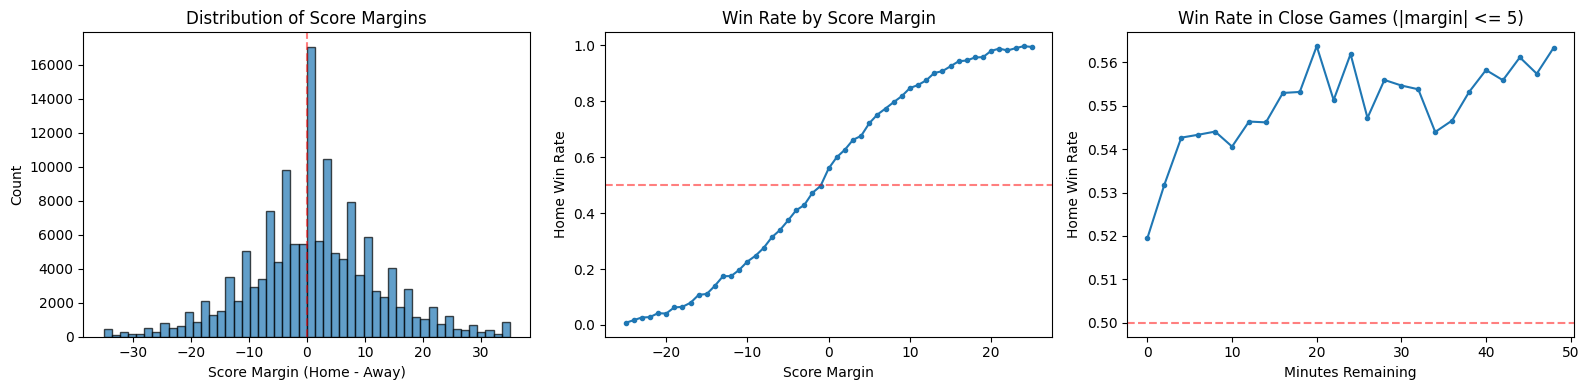

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_snaps['SCORE_MARGIN'].clip(-35, 35), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Score Margin (Home - Away)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Score Margins')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

margin_wr = train_snaps.groupby(
    train_snaps['SCORE_MARGIN'].clip(-25, 25)
)['HOME_WIN'].mean()
axes[1].plot(margin_wr.index, margin_wr.values, 'o-', markersize=3)
axes[1].set_xlabel('Score Margin')
axes[1].set_ylabel('Home Win Rate')
axes[1].set_title('Win Rate by Score Margin')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

close = train_snaps[train_snaps['SCORE_MARGIN'].between(-5, 5)]
time_wr = close.groupby('SECONDS_REMAINING')['HOME_WIN'].mean()
axes[2].plot(time_wr.index / 60, time_wr.values, 'o-', markersize=3)
axes[2].set_xlabel('Minutes Remaining')
axes[2].set_ylabel('Home Win Rate')
axes[2].set_title('Win Rate in Close Games (|margin| <= 5)')
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/01_eda_checks.png', dpi=150, bbox_inches='tight')
plt.show()

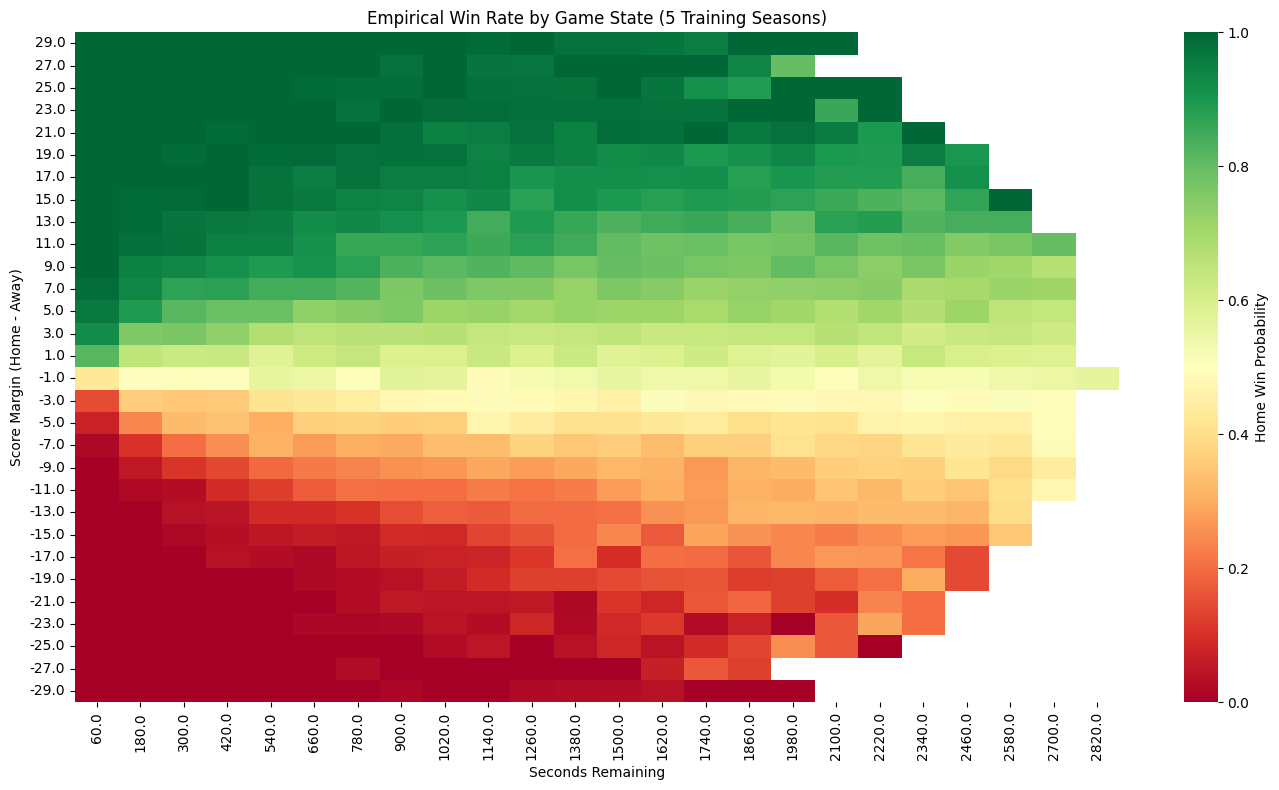

In [10]:
heatmap_data = binned.pivot(index='MARGIN_BIN', columns='TIME_BIN', values='win_rate')

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data.sort_index(ascending=False), 
    cmap='RdYlGn', center=0.5, vmin=0, vmax=1,
    cbar_kws={'label': 'Home Win Probability'}
)
plt.xlabel('Seconds Remaining')
plt.ylabel('Score Margin (Home - Away)')
plt.title('Empirical Win Rate by Game State (5 Training Seasons)')
plt.tight_layout()
plt.savefig('figures/01_empirical_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3: Baseline Models

In [11]:
# Prepare features
X_train = train_snaps[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
y_train = train_snaps['HOME_WIN'].values
X_test = test_snaps[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
y_test = test_snaps['HOME_WIN'].values

scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

# Baseline 1: Simple Logistic Regression
lr_simple = LogisticRegression(max_iter=1000)
lr_simple.fit(X_train_scaled, y_train)
lr_simple_probs = lr_simple.predict_proba(X_test_scaled)[:, 1]

# Baseline 2: Polynomial Logistic Regression (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lr_poly = LogisticRegression(max_iter=2000, C=1.0)
lr_poly.fit(X_train_poly, y_train)
lr_poly_probs = lr_poly.predict_proba(X_test_poly)[:, 1]

# Baseline 3: XGBoost
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    eval_metric='logloss', verbosity=0, random_state=42
)
xgb.fit(X_train_scaled, y_train)
xgb_probs = xgb.predict_proba(X_test_scaled)[:, 1]

print('All baselines fitted.')
print(f'\n{"Model":<35} {"Log-Loss":>8} {"Brier":>8} {"Acc":>8}')
print('=' * 63)
for name, probs in [('Logistic Regression (simple)', lr_simple_probs),
                     ('Logistic Regression (poly deg 3)', lr_poly_probs),
                     ('XGBoost', xgb_probs)]:
    p = np.clip(probs, 0.001, 0.999)
    print(f'{name:<35} {log_loss(y_test, p):>8.4f} {brier_score_loss(y_test, p):>8.4f} {accuracy_score(y_test, (p > 0.5).astype(int)):>8.4f}')

All baselines fitted.

Model                               Log-Loss    Brier      Acc
Logistic Regression (simple)          0.4998   0.1674   0.7481
Logistic Regression (poly deg 3)      0.4804   0.1627   0.7494
XGBoost                               0.4766   0.1618   0.7497


---
## Part 4: GP Kernel Comparison (Bayesian Model Selection)

In [12]:
# Prepare binned data
X_binned = binned[['MARGIN_BIN', 'TIME_BIN']].values
y_binned = binned['win_rate'].values
weights = binned['count'].values

scaler_gp = StandardScaler()
X_binned_scaled = scaler_gp.fit_transform(X_binned)

print(f'GP training points: {len(X_binned)}')
print(f'Win rate range: {y_binned.min():.3f} to {y_binned.max():.3f}')
print(f'Observations per bin: min={weights.min()}, mean={weights.mean():.0f}, max={weights.max()}')

GP training points: 634
Win rate range: 0.000 to 1.000
Observations per bin: min=5, mean=226, max=5730


In [13]:
# Compare kernels with standard noise (for model selection table)
kernels = {
    'RBF': ConstantKernel(1.0) * RBF(length_scale=[1.0, 1.0]) + WhiteKernel(noise_level=0.01),
    'Matern 2.5': ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=2.5) + WhiteKernel(noise_level=0.01),
    'Matern 1.5': ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=1.5) + WhiteKernel(noise_level=0.01),
    'Rational Quadratic': ConstantKernel(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0) + WhiteKernel(noise_level=0.01),
    'RBF + Matern 1.5': ConstantKernel(0.5) * RBF(length_scale=[1.0, 1.0]) + ConstantKernel(0.5) * Matern(length_scale=[1.0, 1.0], nu=1.5) + WhiteKernel(noise_level=0.01),
}

kernel_results = {}
for name, kernel in kernels.items():
    print(f'Fitting {name}...', end=' ')
    gp = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=5,
        normalize_y=True, alpha=1.0 / weights
    )
    gp.fit(X_binned_scaled, y_binned)
    lml = gp.log_marginal_likelihood_value_
    kernel_results[name] = {'model': gp, 'lml': lml, 'kernel': gp.kernel_}
    print(f'LML = {lml:.2f}')

best_kernel_name = max(kernel_results, key=lambda k: kernel_results[k]['lml'])

print(f'\n=== Kernel Comparison (Bayesian Model Selection) ===')
print(f'{"Kernel":<25} {"Log Marginal Likelihood":>25}')
print('-' * 52)
for name in sorted(kernel_results, key=lambda k: kernel_results[k]['lml'], reverse=True):
    lml = kernel_results[name]['lml']
    marker = ' <-- BEST' if name == best_kernel_name else ''
    print(f'{name:<25} {lml:>25.2f}{marker}')

Fitting RBF... LML = 577.90
Fitting Matern 2.5... LML = 587.15
Fitting Matern 1.5... LML = 587.23
Fitting Rational Quadratic... LML = 557.74
Fitting RBF + Matern 1.5... LML = 589.68

=== Kernel Comparison (Bayesian Model Selection) ===
Kernel                      Log Marginal Likelihood
----------------------------------------------------
RBF + Matern 1.5                             589.68 <-- BEST
Matern 1.5                                   587.23
Matern 2.5                                   587.15
RBF                                          577.90
Rational Quadratic                           557.74


---
## Part 5: Refit Best Kernel with Calibrated Noise

In [29]:
white_kernel = WhiteKernel(noise_level=0.05, noise_level_bounds=(0.01, 1.0))
kernel_refit = (ConstantKernel(0.5) * RBF(length_scale=[1.0, 1.0]) + 
                ConstantKernel(0.5) * Matern(length_scale=[1.0, 1.0], nu=1.5) + 
                white_kernel)

best_gp = GaussianProcessRegressor(
    kernel=kernel_refit,
    n_restarts_optimizer=10,
    normalize_y=True,
    alpha=0.01
)
best_gp.fit(X_binned_scaled, y_binned)
print(f'Refitted LML: {best_gp.log_marginal_likelihood_value_:.2f}')
print(f'Optimized kernel: {best_gp.kernel_}')

Refitted LML: 465.05
Optimized kernel: 0.988**2 * RBF(length_scale=[0.722, 4.99]) + 0.262**2 * Matern(length_scale=[1.13, 2.94], nu=1.5) + WhiteKernel(noise_level=0.01)


---
## Part 6: Posterior Predictive Surface

In [30]:
margin_range = np.arange(-30, 31, 1)
time_range = np.arange(0, 2881, 60)

margin_grid, time_grid = np.meshgrid(margin_range, time_range)
X_grid = np.column_stack([margin_grid.ravel(), time_grid.ravel()])
X_grid_scaled = scaler_gp.transform(X_grid)

print('Generating posterior predictions...')
y_pred, y_std = best_gp.predict(X_grid_scaled, return_std=True)
y_pred = np.clip(y_pred, 0, 1)

pred_surface = y_pred.reshape(margin_grid.shape)
std_surface = y_std.reshape(margin_grid.shape)

print(f'Posterior mean range: {y_pred.min():.3f} to {y_pred.max():.3f}')
print(f'Posterior std range: {y_std.min():.4f} to {y_std.max():.4f}')

Generating posterior predictions...
Posterior mean range: 0.000 to 1.000
Posterior std range: 0.0379 to 0.0833


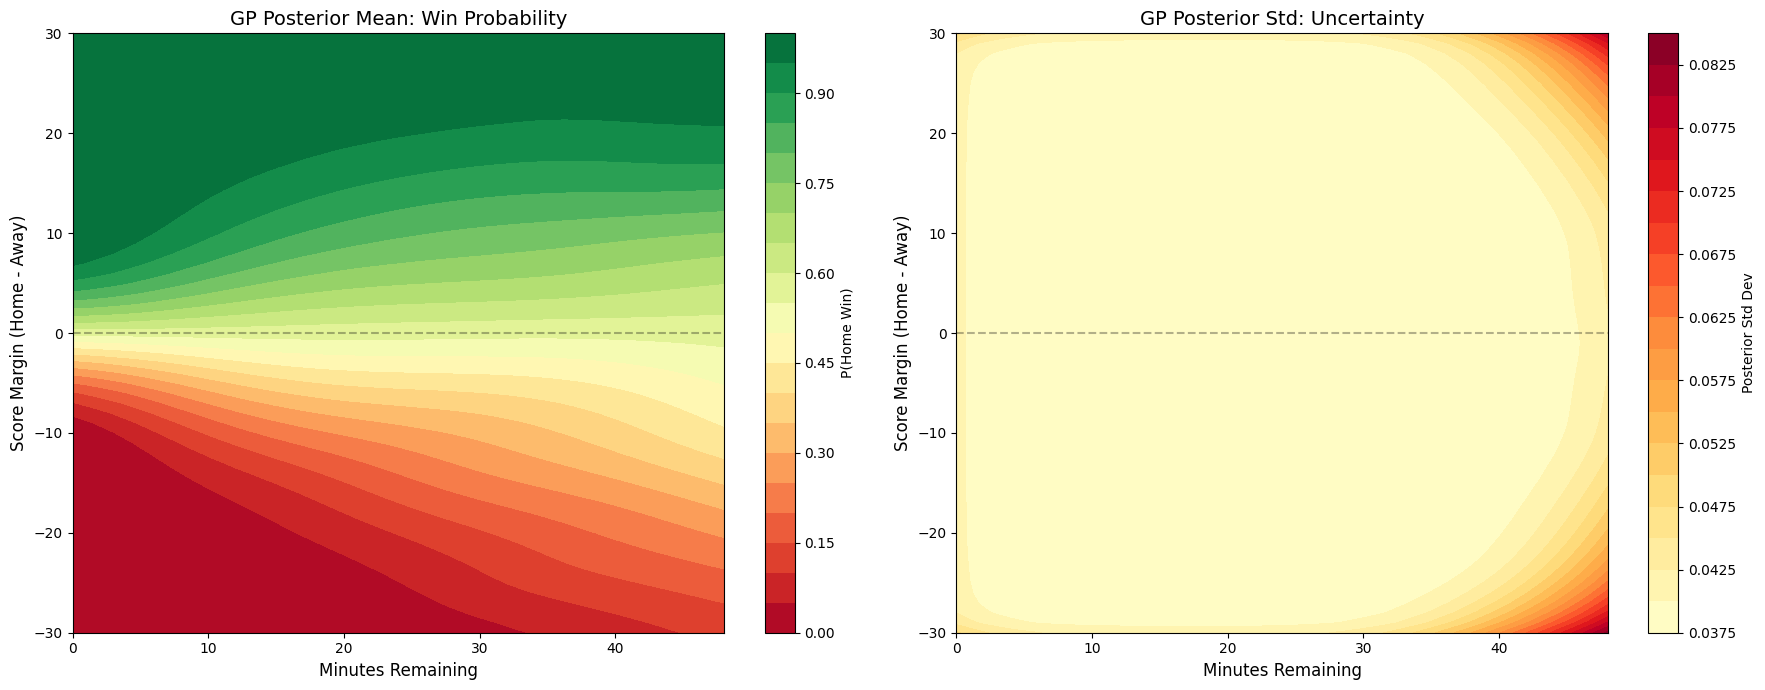

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im1 = axes[0].contourf(
    time_grid / 60, margin_grid, pred_surface,
    levels=np.linspace(0, 1, 21), cmap='RdYlGn'
)
axes[0].set_xlabel('Minutes Remaining', fontsize=12)
axes[0].set_ylabel('Score Margin (Home - Away)', fontsize=12)
axes[0].set_title('GP Posterior Mean: Win Probability', fontsize=14)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
plt.colorbar(im1, ax=axes[0], label='P(Home Win)')

im2 = axes[1].contourf(
    time_grid / 60, margin_grid, std_surface,
    levels=20, cmap='YlOrRd'
)
axes[1].set_xlabel('Minutes Remaining', fontsize=12)
axes[1].set_ylabel('Score Margin (Home - Away)', fontsize=12)
axes[1].set_title('GP Posterior Std: Uncertainty', fontsize=14)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
plt.colorbar(im2, ax=axes[1], label='Posterior Std Dev')

plt.tight_layout()
plt.savefig('figures/02_gp_surfaces.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Part 7: Full Model Evaluation

In [32]:
# GP predictions on test set
X_test_raw = test_snaps[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
X_test_gp_scaled = scaler_gp.transform(X_test_raw)

gp_pred_mean, gp_pred_std = best_gp.predict(X_test_gp_scaled, return_std=True)
gp_pred_mean = np.clip(gp_pred_mean, 0.001, 0.999)
y_test_gp = test_snaps['HOME_WIN'].values

# All models in one table
all_models = {
    'Logistic Regression (simple)': lr_simple_probs,
    'Logistic Regression (poly deg 3)': lr_poly_probs,
    'XGBoost': xgb_probs,
    'Gaussian Process (Matern 1.5)': gp_pred_mean,
}

print('=' * 63)
print(f'{"Model":<35} {"Log-Loss":>8} {"Brier":>8} {"Acc":>8}')
print('=' * 63)
for name, probs in all_models.items():
    p = np.clip(probs, 0.001, 0.999)
    print(f'{name:<35} {log_loss(y_test_gp, p):>8.4f} {brier_score_loss(y_test_gp, p):>8.4f} {accuracy_score(y_test_gp, (p > 0.5).astype(int)):>8.4f}')
print('=' * 63)

Model                               Log-Loss    Brier      Acc
Logistic Regression (simple)          0.4998   0.1674   0.7481
Logistic Regression (poly deg 3)      0.4804   0.1627   0.7494
XGBoost                               0.4766   0.1618   0.7497
Gaussian Process (Matern 1.5)         0.4831   0.1636   0.7479


---
## Part 8: Calibration Curves

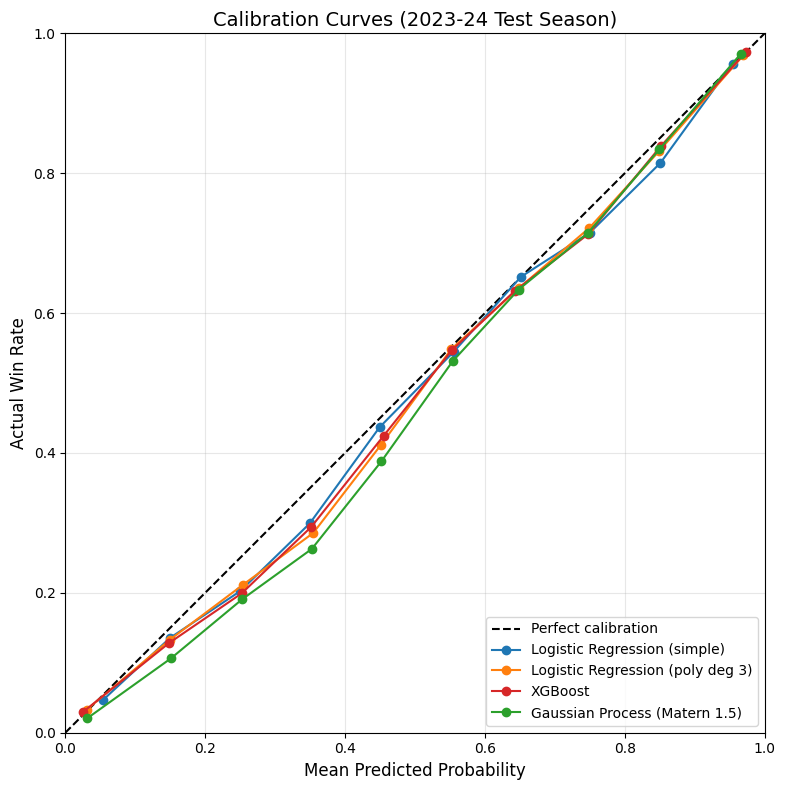

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

colors = {
    'Logistic Regression (simple)': '#1f77b4', 
    'Logistic Regression (poly deg 3)': '#ff7f0e',
    'XGBoost': '#d62728',
    'Gaussian Process (Matern 1.5)': '#2ca02c'
}

for name, probs in all_models.items():
    p = np.clip(probs, 0.001, 0.999)
    fraction_pos, mean_pred = calibration_curve(y_test_gp, p, n_bins=10)
    ax.plot(mean_pred, fraction_pos, 'o-', label=name, color=colors[name], markersize=6)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Actual Win Rate', fontsize=12)
ax.set_title('Calibration Curves (2023-24 Test Season)', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/03_calibration_curves.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Part 9: Bayesian Evaluation (GP-Specific Metrics)

In [34]:
# Interval coverage
for ci_level, z_score in [(0.90, 1.645), (0.95, 1.96)]:
    lower = gp_pred_mean - z_score * gp_pred_std
    upper = gp_pred_mean + z_score * gp_pred_std
    
    coverage_df = pd.DataFrame({
        'pred_mean': gp_pred_mean, 'pred_std': gp_pred_std,
        'lower': lower, 'upper': upper, 'actual': y_test_gp
    })
    
    coverage_df['prob_bin'] = pd.cut(coverage_df['pred_mean'], bins=20)
    bin_stats = coverage_df.groupby('prob_bin').agg(
        actual_rate=('actual', 'mean'),
        mean_lower=('lower', 'mean'),
        mean_upper=('upper', 'mean'),
        count=('actual', 'count')
    ).dropna()
    
    bin_stats['covered'] = (
        (bin_stats['actual_rate'] >= bin_stats['mean_lower']) & 
        (bin_stats['actual_rate'] <= bin_stats['mean_upper'])
    )
    
    coverage = bin_stats['covered'].mean()
    print(f'{ci_level*100:.0f}% Credible Interval Coverage: {coverage:.2%} ({bin_stats["covered"].sum()}/{len(bin_stats)} bins)')

# Posterior sharpness
interval_width_90 = 2 * 1.645 * gp_pred_std
print(f'\nPosterior Sharpness (avg 90% interval width): {interval_width_90.mean():.4f}')
print(f'Posterior Sharpness (median 90% interval width): {np.median(interval_width_90):.4f}')

90% Credible Interval Coverage: 80.00% (16/20 bins)
95% Credible Interval Coverage: 80.00% (16/20 bins)

Posterior Sharpness (avg 90% interval width): 0.1331
Posterior Sharpness (median 90% interval width): 0.1250


---
## Part 10: Epistemic vs Aleatoric Uncertainty Analysis

In [35]:
# Context uncertainty
test_analysis = test_snaps.copy()
test_analysis['gp_mean'] = gp_pred_mean
test_analysis['gp_std'] = gp_pred_std

test_analysis['context'] = 'Normal'
test_analysis.loc[
    (test_analysis['SCORE_MARGIN'].abs() <= 5) & 
    (test_analysis['SECONDS_REMAINING'] <= 300), 'context'
] = 'Clutch (|margin|<=5, <5min)'
test_analysis.loc[
    test_analysis['SCORE_MARGIN'].abs() >= 15, 'context'
] = 'Blowout (|margin|>=15)'

context_stats = test_analysis.groupby('context').agg(
    mean_epistemic=('gp_std', 'mean'),
    median_epistemic=('gp_std', 'median'),
    count=('gp_std', 'count')
)

print('=== Posterior (Epistemic) Uncertainty by Game Context ===')
print(context_stats.to_string())

=== Posterior (Epistemic) Uncertainty by Game Context ===
                             mean_epistemic  median_epistemic  count
context                                                             
Blowout (|margin|>=15)             0.048022          0.038062   6231
Clutch (|margin|<=5, <5min)        0.039340          0.039121    988
Normal                             0.038487          0.037984  23531


In [36]:
# Epistemic vs Aleatoric side-by-side
# Epistemic: GP posterior std (model uncertainty from data scarcity)
# Aleatoric proxy: distance of predicted probability from 0.5 (closer = more random)

test_analysis['epistemic'] = test_analysis['gp_std']
test_analysis['aleatoric_proxy'] = 0.5 - np.abs(test_analysis['gp_mean'] - 0.5)
# aleatoric_proxy is high (near 0.5) when prediction is near 0.5 (uncertain outcome)
# aleatoric_proxy is low (near 0) when prediction is near 0 or 1 (certain outcome)

context_full = test_analysis.groupby('context').agg(
    epistemic_mean=('epistemic', 'mean'),
    aleatoric_mean=('aleatoric_proxy', 'mean'),
    count=('epistemic', 'count')
).round(4)

print('=== Epistemic vs Aleatoric Uncertainty by Context ===')
print(context_full.to_string())
print()
print('Interpretation:')
print('  Blowout: HIGH epistemic (sparse data), LOW aleatoric (outcome is obvious)')
print('  Clutch:  LOW epistemic (dense data), HIGH aleatoric (coin-flip outcomes)')
print('  Normal:  LOW epistemic (dense data), MODERATE aleatoric')

=== Epistemic vs Aleatoric Uncertainty by Context ===
                             epistemic_mean  aleatoric_mean  count
context                                                           
Blowout (|margin|>=15)               0.0480          0.0527   6231
Clutch (|margin|<=5, <5min)          0.0393          0.3142    988
Normal                               0.0385          0.3145  23531

Interpretation:
  Blowout: HIGH epistemic (sparse data), LOW aleatoric (outcome is obvious)
  Clutch:  LOW epistemic (dense data), HIGH aleatoric (coin-flip outcomes)
  Normal:  LOW epistemic (dense data), MODERATE aleatoric


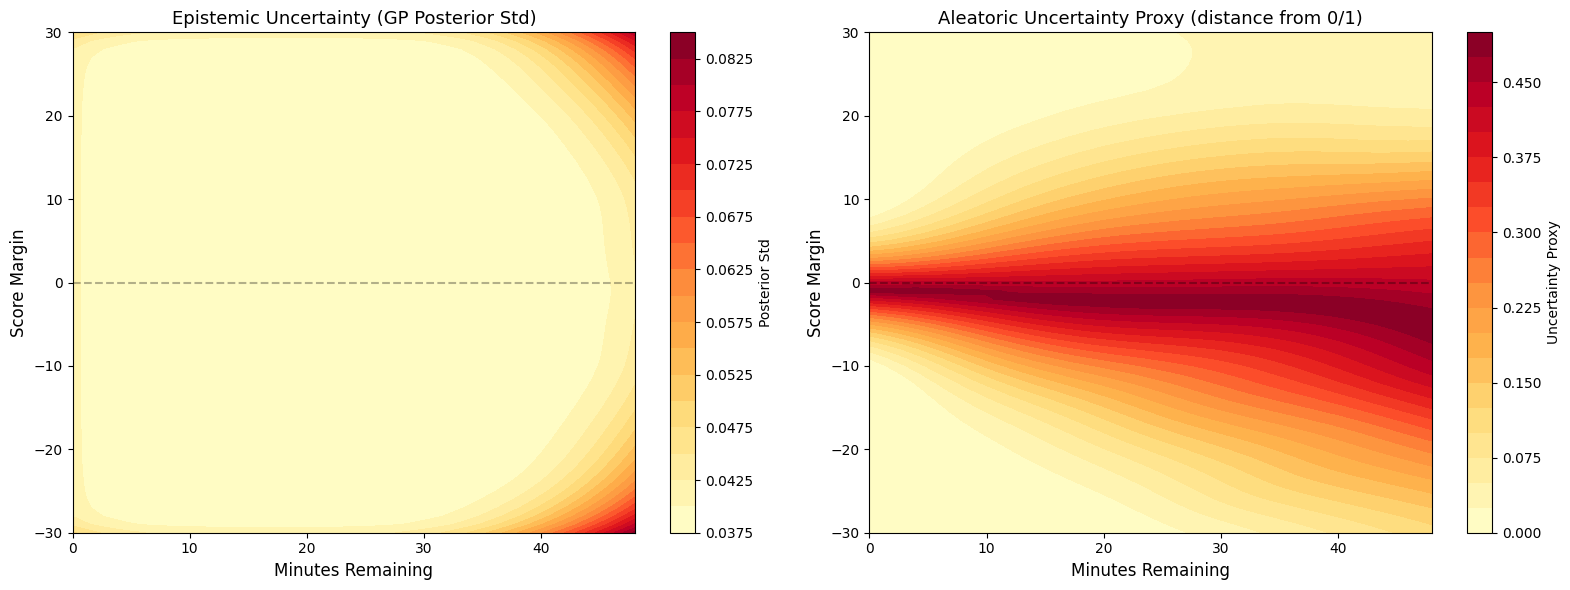

In [37]:
# Visualization: epistemic vs aleatoric
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Epistemic uncertainty surface (GP posterior std)
im1 = axes[0].contourf(
    time_grid / 60, margin_grid, std_surface,
    levels=20, cmap='YlOrRd'
)
axes[0].set_xlabel('Minutes Remaining', fontsize=12)
axes[0].set_ylabel('Score Margin', fontsize=12)
axes[0].set_title('Epistemic Uncertainty (GP Posterior Std)', fontsize=13)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
plt.colorbar(im1, ax=axes[0], label='Posterior Std')

# Aleatoric proxy surface (distance of prediction from 0.5)
aleatoric_surface = 0.5 - np.abs(pred_surface - 0.5)
im2 = axes[1].contourf(
    time_grid / 60, margin_grid, aleatoric_surface,
    levels=20, cmap='YlOrRd'
)
axes[1].set_xlabel('Minutes Remaining', fontsize=12)
axes[1].set_ylabel('Score Margin', fontsize=12)
axes[1].set_title('Aleatoric Uncertainty Proxy (distance from 0/1)', fontsize=13)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
plt.colorbar(im2, ax=axes[1], label='Uncertainty Proxy')

plt.tight_layout()
plt.savefig('figures/04_epistemic_vs_aleatoric.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Part 11: Calibration by Game Phase

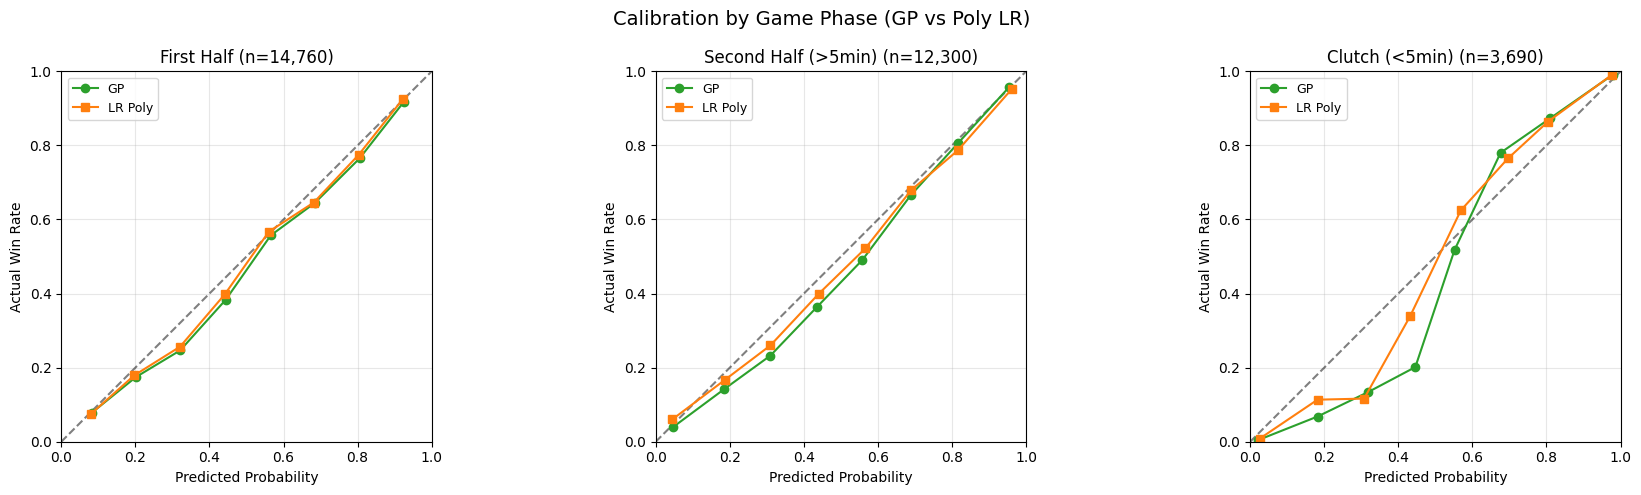

In [38]:
# Split test data into game phases
test_analysis['phase'] = 'First Half'
test_analysis.loc[
    (test_analysis['SECONDS_REMAINING'] <= 1440) & 
    (test_analysis['SECONDS_REMAINING'] > 300), 'phase'
] = 'Second Half (>5min)'
test_analysis.loc[
    test_analysis['SECONDS_REMAINING'] <= 300, 'phase'
] = 'Clutch (<5min)'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, phase in enumerate(['First Half', 'Second Half (>5min)', 'Clutch (<5min)']):
    mask = test_analysis['phase'] == phase
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
    # GP calibration for this phase
    gp_phase = np.clip(test_analysis.loc[mask, 'gp_mean'].values, 0.001, 0.999)
    y_phase = test_analysis.loc[mask, 'HOME_WIN'].values
    
    if len(np.unique(y_phase)) > 1:
        frac, mean_p = calibration_curve(y_phase, gp_phase, n_bins=8)
        ax.plot(mean_p, frac, 'o-', color='#2ca02c', label='GP', markersize=6)
    
    # LR poly calibration for this phase
    lr_phase = np.clip(lr_poly_probs[mask], 0.001, 0.999)
    if len(np.unique(y_phase)) > 1:
        frac, mean_p = calibration_curve(y_phase, lr_phase, n_bins=8)
        ax.plot(mean_p, frac, 's-', color='#ff7f0e', label='LR Poly', markersize=6)
    
    ax.set_title(f'{phase} (n={mask.sum():,})', fontsize=12)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Calibration by Game Phase (GP vs Poly LR)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/05_calibration_by_phase.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Part 12: Game Trajectory Overlays

In [39]:
# Find interesting games in test set
test_games = test_snaps.groupby('GAME_ID').agg(
    final_margin=('SCORE_MARGIN', 'last'),
    max_margin=('SCORE_MARGIN', 'max'),
    min_margin=('SCORE_MARGIN', 'min'),
    margin_range=('SCORE_MARGIN', lambda x: x.max() - x.min()),
    home_win=('HOME_WIN', 'first')
).reset_index()

# Comebacks
comebacks = test_games[(test_games['home_win'] == 1) & (test_games['min_margin'] < -10)]
comebacks = comebacks.sort_values('min_margin').head(5)
print('=== TOP COMEBACKS ===')
print(comebacks[['GAME_ID', 'min_margin', 'final_margin']].to_string())

# Close finishes
close_finish = test_games[test_games['final_margin'].abs() <= 3].sample(5, random_state=42)
print('\n=== CLOSE FINISHES ===')
print(close_finish[['GAME_ID', 'final_margin', 'home_win']].to_string())

# GP was confidently wrong: high predicted win prob but home lost
test_with_pred = test_snaps.copy()
test_with_pred['gp_mean'] = gp_pred_mean

# Look at game-level: average GP prediction was high but home lost
game_avg = test_with_pred.groupby('GAME_ID').agg(
    avg_gp=('gp_mean', 'mean'),
    home_win=('HOME_WIN', 'first')
).reset_index()

confident_wrong = game_avg[(game_avg['home_win'] == 0) & (game_avg['avg_gp'] > 0.65)]
confident_wrong = confident_wrong.sort_values('avg_gp', ascending=False).head(5)
print('\n=== GP CONFIDENTLY WRONG (predicted home win, home lost) ===')
print(confident_wrong[['GAME_ID', 'avg_gp', 'home_win']].to_string())

=== TOP COMEBACKS ===
       GAME_ID  min_margin  final_margin
1033  22301034       -27.0           2.0
244   22300245       -26.0           6.0
1131  22301132       -26.0           2.0
188   22300189       -23.0           4.0
722   22300723       -23.0           0.0

=== CLOSE FINISHES ===
       GAME_ID  final_margin  home_win
39    22300040           0.0         0
1132  22301133           2.0         1
307   22300308           3.0         1
1101  22301102          -3.0         0
637   22300638           1.0         1

=== GP CONFIDENTLY WRONG (predicted home win, home lost) ===
       GAME_ID    avg_gp  home_win
112   22300113  0.828004         0
1044  22301045  0.821597         0
140   22300141  0.792601         0
740   22300741  0.782892         0
419   22300420  0.764468         0


In [40]:
def plot_game_trajectory(game_id, ax, title=None):
    game = test_snaps[test_snaps['GAME_ID'] == game_id].sort_values('SECONDS_REMAINING', ascending=False)
    if len(game) == 0:
        print(f'Game {game_id} not found')
        return
    
    X_game = game[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
    X_game_scaled = scaler_gp.transform(X_game)
    gp_mean, gp_std = best_gp.predict(X_game_scaled, return_std=True)
    gp_mean = np.clip(gp_mean, 0, 1)
    
    minutes_elapsed = (2880 - game['SECONDS_REMAINING'].values) / 60
    home_win = game['HOME_WIN'].iloc[0]
    
    ax.plot(minutes_elapsed, gp_mean, 'b-', linewidth=2, label='GP Posterior Mean')
    ax.fill_between(
        minutes_elapsed, 
        np.clip(gp_mean - 1.96 * gp_std, 0, 1),
        np.clip(gp_mean + 1.96 * gp_std, 0, 1),
        alpha=0.2, color='blue', label='95% Credible Interval'
    )
    ax.fill_between(
        minutes_elapsed,
        np.clip(gp_mean - 1.645 * gp_std, 0, 1),
        np.clip(gp_mean + 1.645 * gp_std, 0, 1),
        alpha=0.3, color='blue', label='90% Credible Interval'
    )
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(home_win, color='red', linestyle=':', alpha=0.5, 
               label=f'Outcome: {"Home Win" if home_win else "Home Loss"}')
    for q in [12, 24, 36]:
        ax.axvline(q, color='gray', linestyle=':', alpha=0.2)
    
    ax.set_xlabel('Minutes Elapsed')
    ax.set_ylabel('P(Home Win)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(0, 48)
    ax.legend(loc='best', fontsize=7)
    if title:
        ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)

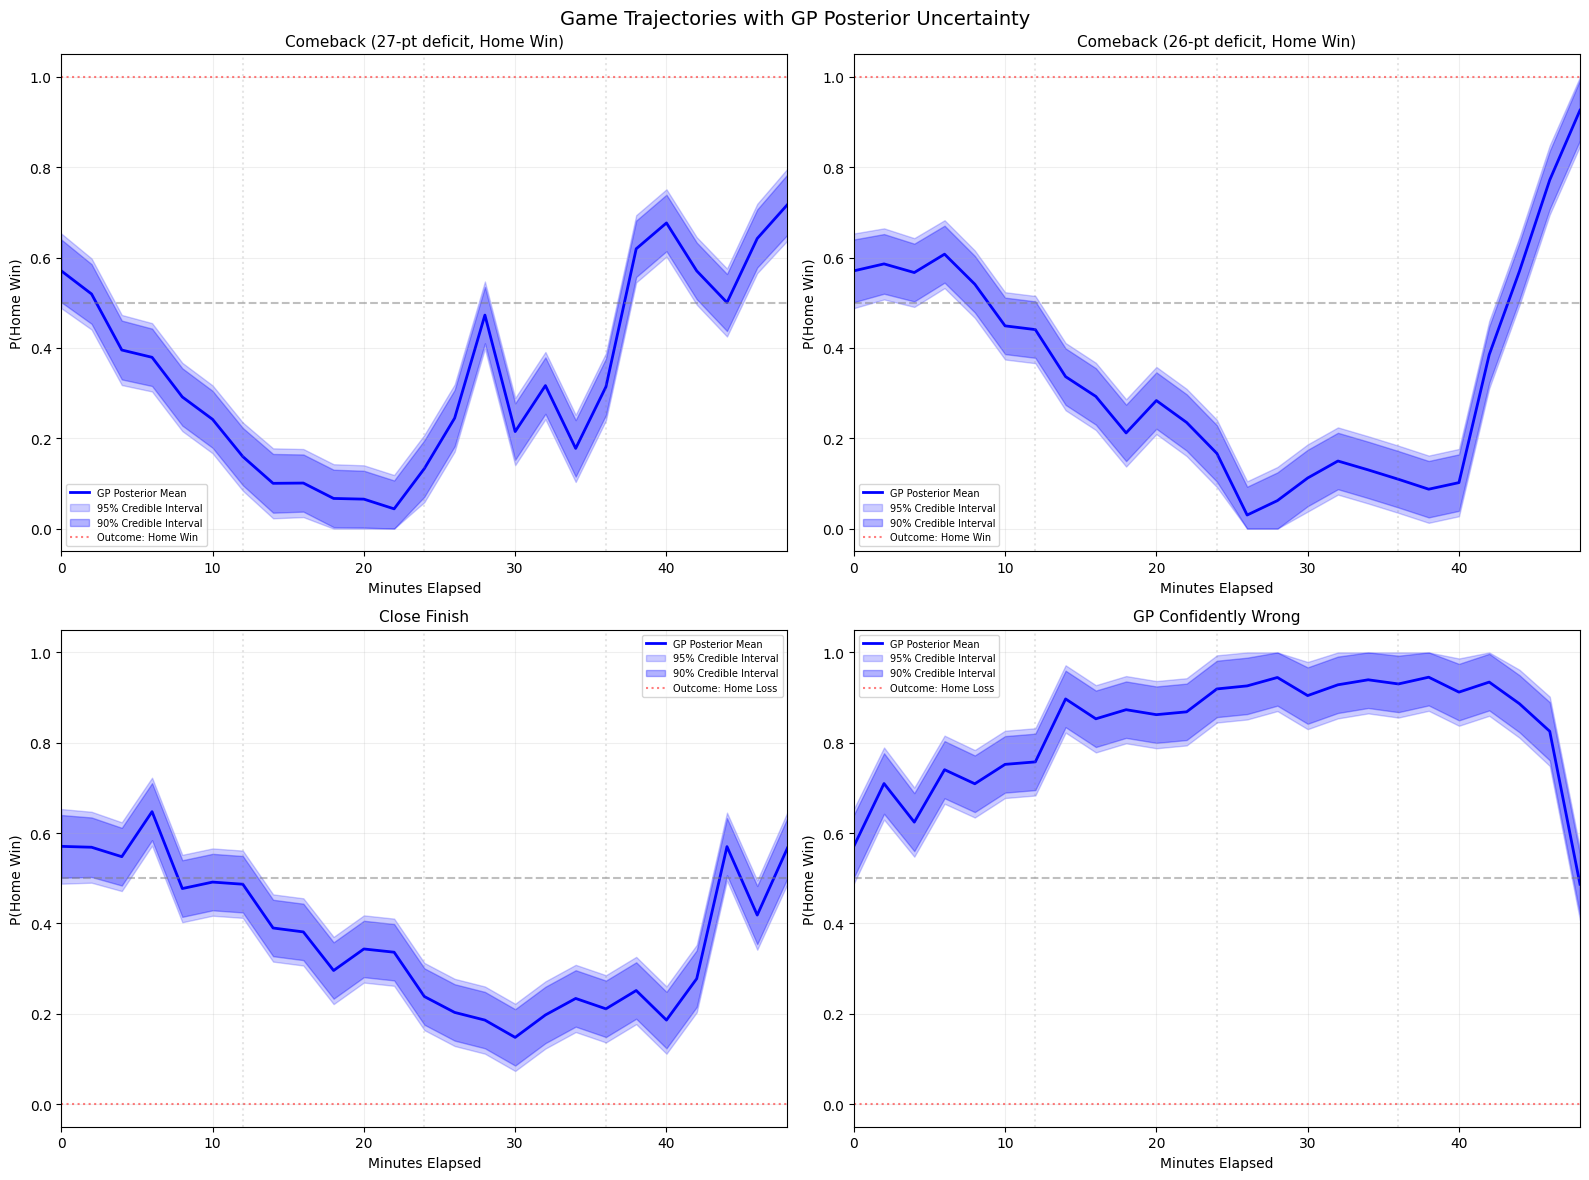

In [41]:
# Four trajectories: two comebacks, one close finish, one confidently wrong
comeback_1_id = comebacks['GAME_ID'].iloc[0]
comeback_2_id = comebacks['GAME_ID'].iloc[1]
close_id = close_finish['GAME_ID'].iloc[0]
wrong_id = confident_wrong['GAME_ID'].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_game_trajectory(comeback_1_id, axes[0, 0], title='Comeback (27-pt deficit, Home Win)')
plot_game_trajectory(comeback_2_id, axes[0, 1], title='Comeback (26-pt deficit, Home Win)')
plot_game_trajectory(close_id, axes[1, 0], title='Close Finish')
plot_game_trajectory(wrong_id, axes[1, 1], title='GP Confidently Wrong')

plt.suptitle('Game Trajectories with GP Posterior Uncertainty', fontsize=14)
plt.tight_layout()
plt.savefig('figures/06_game_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Part 13: Rolling Temporal Validation

In [42]:
# Test GP stability: train on expanding window, test on next season
# Split 1: train 2018-22, test 2022-23
# Split 2: train 2018-23, test 2023-24

validation_splits = [
    {
        'name': 'Train 2018-22, Test 2022-23',
        'train': ['2018-19', '2019-20', '2020-21', '2021-22'],
        'test': '2022-23'
    },
    {
        'name': 'Train 2018-23, Test 2023-24',
        'train': ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23'],
        'test': '2023-24'
    }
]

print('=== Rolling Temporal Validation ===')
print(f'{"Split":<35} {"GP Log-Loss":>10} {"GP Brier":>10} {"LR Log-Loss":>10} {"LR Brier":>10}')
print('=' * 80)

for split in validation_splits:
    # Prepare train/test for this split
    tr = df_snapshots[df_snapshots['SEASON'].isin(split['train'])].copy()
    te = df_snapshots[df_snapshots['SEASON'] == split['test']].copy()
    
    # Bin training data
    tr['MARGIN_BIN'] = pd.cut(tr['SCORE_MARGIN'].clip(-30, 30), bins=margin_bins, labels=margin_bins[:-1]+1, include_lowest=True)
    tr['TIME_BIN'] = pd.cut(tr['SECONDS_REMAINING'], bins=time_bins, labels=time_bins[:-1]+60, include_lowest=True)
    bn = tr.groupby(['MARGIN_BIN', 'TIME_BIN']).agg(win_rate=('HOME_WIN','mean'), count=('HOME_WIN','count')).reset_index()
    bn = bn[bn['count'] >= 5].copy()
    bn['MARGIN_BIN'] = bn['MARGIN_BIN'].astype(float)
    bn['TIME_BIN'] = bn['TIME_BIN'].astype(float)
    
    X_bn = bn[['MARGIN_BIN', 'TIME_BIN']].values
    y_bn = bn['win_rate'].values
    sc = StandardScaler()
    X_bn_s = sc.fit_transform(X_bn)
    
    # Fit GP
    wk = WhiteKernel(noise_level=0.05, noise_level_bounds=(0.01, 1.0))
    k = ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=1.5) + wk
    gp_val = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=5, normalize_y=True, alpha=0.01)
    gp_val.fit(X_bn_s, y_bn)
    
    # Predict on test
    X_te = te[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
    y_te = te['HOME_WIN'].values
    X_te_s = sc.transform(X_te)
    gp_preds = np.clip(gp_val.predict(X_te_s), 0.001, 0.999)
    
    # Fit LR poly baseline for comparison
    X_tr_lr = tr[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
    y_tr_lr = tr['HOME_WIN'].values
    sc_lr = StandardScaler()
    X_tr_lr_s = sc_lr.fit_transform(X_tr_lr)
    X_te_lr_s = sc_lr.transform(X_te)
    poly_v = PolynomialFeatures(degree=3, include_bias=False)
    X_tr_p = poly_v.fit_transform(X_tr_lr_s)
    X_te_p = poly_v.transform(X_te_lr_s)
    lr_v = LogisticRegression(max_iter=2000)
    lr_v.fit(X_tr_p, y_tr_lr)
    lr_preds = np.clip(lr_v.predict_proba(X_te_p)[:, 1], 0.001, 0.999)
    
    gp_ll = log_loss(y_te, gp_preds)
    gp_bs = brier_score_loss(y_te, gp_preds)
    lr_ll = log_loss(y_te, lr_preds)
    lr_bs = brier_score_loss(y_te, lr_preds)
    
    print(f'{split["name"]:<35} {gp_ll:>10.4f} {gp_bs:>10.4f} {lr_ll:>10.4f} {lr_bs:>10.4f}')

print('=' * 80)

=== Rolling Temporal Validation ===
Split                               GP Log-Loss   GP Brier LR Log-Loss   LR Brier
Train 2018-22, Test 2022-23             0.4969     0.1692     0.4973     0.1696
Train 2018-23, Test 2023-24             0.4819     0.1633     0.4804     0.1627


---
## Part 14: Save Everything

In [43]:
# Save GP model and scalers
with open('data/processed/best_gp_model.pkl', 'wb') as f:
    pickle.dump(best_gp, f)
with open('data/processed/scaler_gp.pkl', 'wb') as f:
    pickle.dump(scaler_gp, f)
with open('data/processed/scaler_lr.pkl', 'wb') as f:
    pickle.dump(scaler_lr, f)

# Save surfaces
np.savez('data/processed/gp_surfaces.npz',
    margin_grid=margin_grid, time_grid=time_grid,
    pred_surface=pred_surface, std_surface=std_surface)

# Save test predictions
test_results = test_snaps.copy()
test_results['gp_mean'] = gp_pred_mean
test_results['gp_std'] = gp_pred_std
test_results['lr_simple_prob'] = lr_simple_probs
test_results['lr_poly_prob'] = lr_poly_probs
test_results['xgb_prob'] = xgb_probs
test_results.to_csv('data/processed/test_predictions.csv', index=False)

# Save snapshots
df_snapshots.to_csv('data/processed/all_snapshots.csv', index=False)

# Save kernel comparison
kdf = pd.DataFrame([
    {'kernel': name, 'log_marginal_likelihood': kernel_results[name]['lml'],
     'optimized_kernel': str(kernel_results[name]['kernel'])}
    for name in kernel_results
]).sort_values('log_marginal_likelihood', ascending=False)
kdf.to_csv('data/processed/kernel_comparison.csv', index=False)

print('All saved.')
print(f'\nFigures generated:')
import os
for f in sorted(os.listdir('figures')):
    print(f'  figures/{f}')

All saved.

Figures generated:
  figures/01_eda_checks.png
  figures/01_empirical_heatmap.png
  figures/01_empirical_winrate_heatmap.png
  figures/02_calibration_curves.png
  figures/02_game_trajectories.png
  figures/02_gp_surfaces.png
  figures/03_calibration_curves.png
  figures/04_epistemic_vs_aleatoric.png
  figures/05_calibration_by_phase.png
  figures/06_game_trajectories.png


---
## Final Checkpoint

**Data:**
- 5 training seasons (~5,800 games), 1 test season (~1,230 games)
- Zero overlap between train and test

**Models compared:**
- Simple Logistic Regression
- Polynomial Logistic Regression (degree 3)
- XGBoost
- Gaussian Process (Matern 1.5, calibrated noise)

**Figures:**
- 01: EDA checks + empirical heatmap
- 02: GP posterior mean + std surfaces
- 03: Calibration curves (all 4 models)
- 04: Epistemic vs aleatoric uncertainty comparison
- 05: Calibration by game phase
- 06: Game trajectories (2 comebacks, 1 close, 1 confidently wrong)

**Ready for paper writing.**

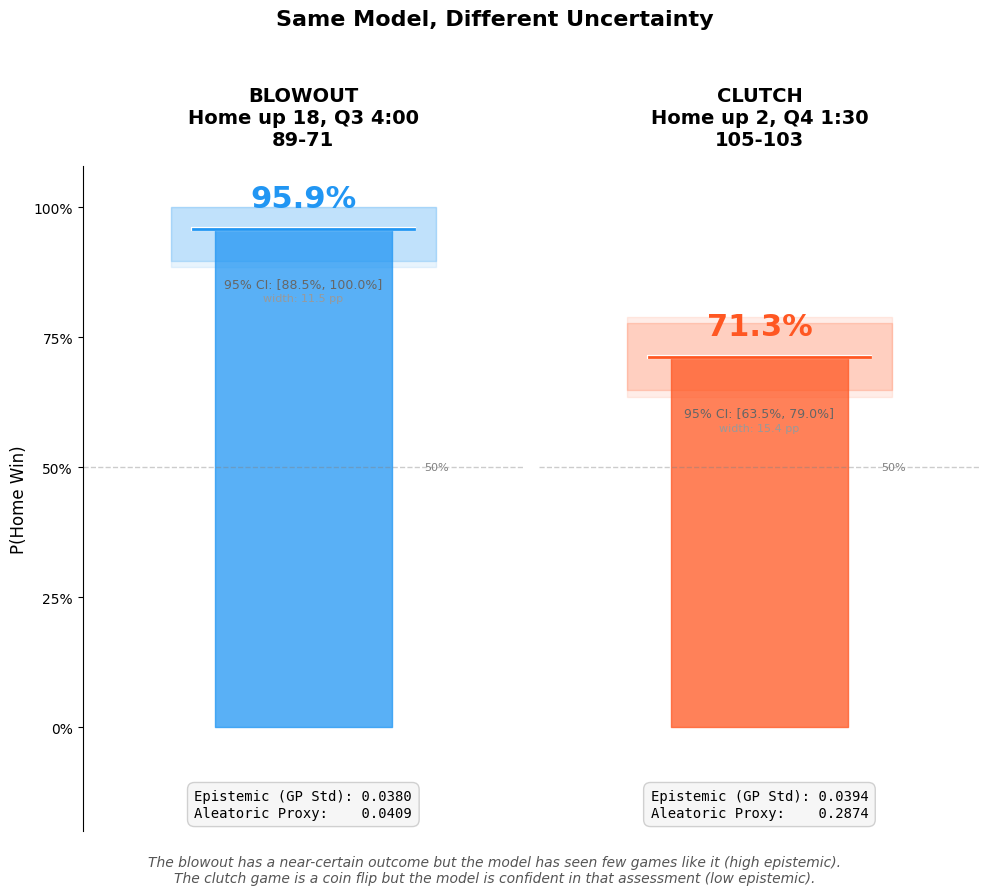

BLOWOUT: Home up 18, Q3 4:00
  P(Home Win):      95.9%
  Epistemic (Std):  0.0380
  Aleatoric Proxy:  0.0409
  95% CI:           [88.5%, 100.0%]

CLUTCH: Home up 2, Q4 1:30
  P(Home Win):      71.3%
  Epistemic (Std):  0.0394
  Aleatoric Proxy:  0.2874
  95% CI:           [63.5%, 79.0%]


In [4]:
# === SIDE-BY-SIDE SCENARIO COMPARISON ===
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as FancyBboxPatch

try:
    best_gp
except NameError:
    with open('data/processed/best_gp_model.pkl', 'rb') as f:
        best_gp = pickle.load(f)
    with open('data/processed/scaler_gp.pkl', 'rb') as f:
        scaler_gp = pickle.load(f)

# === DEFINE SCENARIOS ===
scenario_a = {
    'label': 'BLOWOUT',
    'description': 'Home up 18, Q3 4:00',
    'home_score': 89, 'away_score': 71,
    'quarter': 3, 'minutes': 4, 'seconds': 0
}

scenario_b = {
    'label': 'CLUTCH',
    'description': 'Home up 2, Q4 1:30',
    'home_score': 105, 'away_score': 103,
    'quarter': 4, 'minutes': 1, 'seconds': 30
}

def predict_scenario(s):
    margin = s['home_score'] - s['away_score']
    secs = (4 - s['quarter']) * 720 + s['minutes'] * 60 + s['seconds']
    X = scaler_gp.transform([[margin, secs]])
    prob, std = best_gp.predict(X, return_std=True)
    prob = np.clip(prob[0], 0, 1)
    std = std[0]
    aleatoric = 0.5 - abs(prob - 0.5)
    return {
        'prob': prob, 'std': std, 'aleatoric': aleatoric,
        'ci90': (max(0, prob - 1.645*std), min(1, prob + 1.645*std)),
        'ci95': (max(0, prob - 1.96*std), min(1, prob + 1.96*std)),
    }

a = predict_scenario(scenario_a)
b = predict_scenario(scenario_b)

# === VISUALIZATION ===
fig, axes = plt.subplots(1, 2, figsize=(10, 9), sharey=True)

for ax, scenario, pred, accent in [
    (axes[0], scenario_a, a, '#2196F3'),
    (axes[1], scenario_b, b, '#FF5722')
]:
    # 95% CI band (widest, lightest)
    ax.fill_betweenx(
        [pred['ci95'][0] * 100, pred['ci95'][1] * 100],
        -0.6, 0.6, color=accent, alpha=0.10
    )
    # 90% CI band
    ax.fill_betweenx(
        [pred['ci90'][0] * 100, pred['ci90'][1] * 100],
        -0.6, 0.6, color=accent, alpha=0.20
    )
    
    # Main probability bar from 0 to predicted value
    ax.fill_betweenx(
        [0, pred['prob'] * 100],
        -0.4, 0.4, color=accent, alpha=0.75
    )
    
    # Probability marker line
    ax.plot([-0.5, 0.5], [pred['prob'] * 100, pred['prob'] * 100],
            color='white', linewidth=3, zorder=5)
    ax.plot([-0.5, 0.5], [pred['prob'] * 100, pred['prob'] * 100],
            color=accent, linewidth=2, zorder=6, linestyle='-')
    
    # 50% reference line
    ax.axhline(50, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(0.55, 50, '50%', va='center', ha='left', fontsize=8, color='gray')
    
    # Probability label
    ax.text(0, pred['prob'] * 100 + 3, f"{pred['prob']:.1%}",
            ha='center', va='bottom', fontsize=22, fontweight='bold', color=accent)
    
    # CI label
    ci_width = (pred['ci95'][1] - pred['ci95'][0]) * 100
    ax.text(0, pred['ci95'][0] * 100 - 2,
            f"95% CI: [{pred['ci95'][0]:.1%}, {pred['ci95'][1]:.1%}]",
            ha='center', va='top', fontsize=9, color='#666666')
    ax.text(0, pred['ci95'][0] * 100 - 5,
            f"width: {ci_width:.1f} pp",
            ha='center', va='top', fontsize=8, color='#999999')
    
    # Title block
    ax.set_title(f"{scenario['label']}\n{scenario['description']}\n{scenario['home_score']}-{scenario['away_score']}",
                 fontsize=14, fontweight='bold', pad=15)
    
    # Uncertainty annotation box at bottom
    box_text = (f"Epistemic (GP Std): {pred['std']:.4f}\n"
                f"Aleatoric Proxy:    {pred['aleatoric']:.4f}")
    ax.text(0, -12, box_text, ha='center', va='top', fontsize=10,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                      edgecolor='#cccccc', alpha=0.9))
    
    # Clean up axes
    ax.set_ylim(-20, 108)
    ax.set_xlim(-1, 1)
    ax.set_xticks([])
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

# Only show y-axis labels on left
axes[0].tick_params(left=True, labelleft=True)
axes[0].spines['left'].set_visible(True)
axes[0].set_yticks([0, 25, 50, 75, 100])
axes[0].set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=10)
axes[0].set_ylabel('P(Home Win)', fontsize=12)

plt.suptitle('Same Model, Different Uncertainty', fontsize=16, fontweight='bold', y=0.98)

fig.text(0.5, 0.01,
    'The blowout has a near-certain outcome but the model has seen few games like it (high epistemic).\n'
    'The clutch game is a coin flip but the model is confident in that assessment (low epistemic).',
    ha='center', fontsize=10, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('figures/07_scenario_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# === PRINT SUMMARY ===
print(f'BLOWOUT: {scenario_a["description"]}')
print(f'  P(Home Win):      {a["prob"]:.1%}')
print(f'  Epistemic (Std):  {a["std"]:.4f}')
print(f'  Aleatoric Proxy:  {a["aleatoric"]:.4f}')
print(f'  95% CI:           [{a["ci95"][0]:.1%}, {a["ci95"][1]:.1%}]')
print()
print(f'CLUTCH: {scenario_b["description"]}')
print(f'  P(Home Win):      {b["prob"]:.1%}')
print(f'  Epistemic (Std):  {b["std"]:.4f}')
print(f'  Aleatoric Proxy:  {b["aleatoric"]:.4f}')
print(f'  95% CI:           [{b["ci95"][0]:.1%}, {b["ci95"][1]:.1%}]')

c:\Users\Josh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Josh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


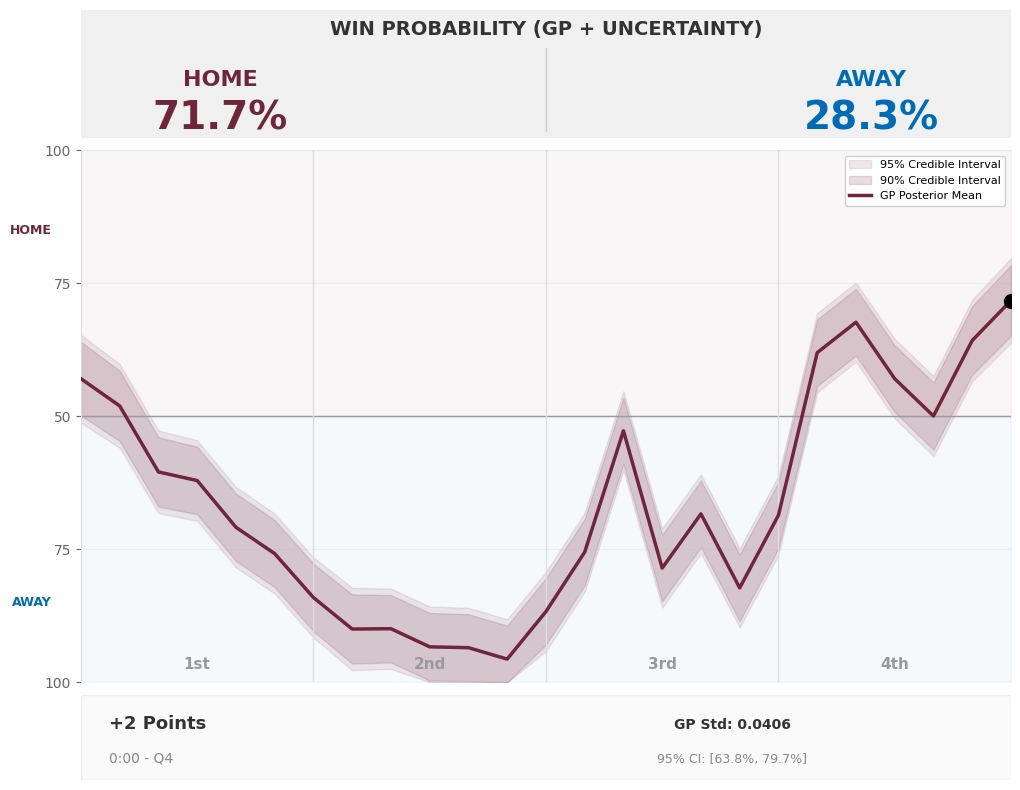

Saved: figures/08_espn_style_winprob.png


In [1]:
# === ESPN-STYLE WIN PROBABILITY WITH GP UNCERTAINTY ===
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

try:
    best_gp
except NameError:
    with open('data/processed/best_gp_model.pkl', 'rb') as f:
        best_gp = pickle.load(f)
    with open('data/processed/scaler_gp.pkl', 'rb') as f:
        scaler_gp = pickle.load(f)

snapshots = pd.read_csv('data/processed/all_snapshots.csv')
test_snaps = snapshots[snapshots['SEASON'] == '2023-24'].copy()

# === PICK A GAME (use a comeback for max drama) ===
test_games = test_snaps.groupby('GAME_ID').agg(
    final_margin=('SCORE_MARGIN', 'last'),
    min_margin=('SCORE_MARGIN', 'min'),
    max_margin=('SCORE_MARGIN', 'max'),
    home_win=('HOME_WIN', 'first')
).reset_index()

comebacks = test_games[(test_games['home_win'] == 1) & (test_games['min_margin'] < -15)]
comebacks = comebacks.sort_values('min_margin')
game_id = comebacks['GAME_ID'].iloc[0]

# === YOU CAN CUSTOMIZE THESE ===
home_team = 'HOME'
away_team = 'AWAY'
home_color = '#6F263D'   # dark red (Cavs-style)
away_color = '#006BB6'   # blue (Knicks-style)
# ================================

game = test_snaps[test_snaps['GAME_ID'] == game_id].sort_values('SECONDS_REMAINING', ascending=False)

X_game = game[['SCORE_MARGIN', 'SECONDS_REMAINING']].values
X_game_scaled = scaler_gp.transform(X_game)
gp_mean, gp_std = best_gp.predict(X_game_scaled, return_std=True)
gp_mean = np.clip(gp_mean, 0, 1)

minutes_elapsed = (2880 - game['SECONDS_REMAINING'].values) / 60
margins = game['SCORE_MARGIN'].values
home_win = game['HOME_WIN'].iloc[0]

# Current state (last snapshot)
current_prob = gp_mean[-1]
current_margin = margins[-1]
final_home_score = '--'
final_away_score = '--'

# === BUILD THE FIGURE ===
fig = plt.figure(figsize=(12, 10), facecolor='white')

# Layout: header, main chart, footer
gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 5, 0.8], hspace=0.05)

# --- HEADER ---
ax_header = fig.add_subplot(gs[0])
ax_header.set_xlim(0, 10)
ax_header.set_ylim(0, 1)
ax_header.axis('off')

# Background
ax_header.add_patch(plt.Rectangle((0, 0), 10, 1, facecolor='#f0f0f0',
                                   edgecolor='none', transform=ax_header.transData))

# Title
ax_header.text(5, 0.85, 'WIN PROBABILITY (GP + UNCERTAINTY)', 
               ha='center', va='center', fontsize=14, fontweight='bold', color='#333333')

# Home team side
ax_header.text(1.5, 0.45, home_team, ha='center', va='center',
               fontsize=16, fontweight='bold', color=home_color)
home_pct = gp_mean[-1] * 100
ax_header.text(1.5, 0.15, f'{home_pct:.1f}%', ha='center', va='center',
               fontsize=28, fontweight='bold', color=home_color)

# Away team side
ax_header.text(8.5, 0.45, away_team, ha='center', va='center',
               fontsize=16, fontweight='bold', color=away_color)
away_pct = (1 - gp_mean[-1]) * 100
ax_header.text(8.5, 0.15, f'{away_pct:.1f}%', ha='center', va='center',
               fontsize=28, fontweight='bold', color=away_color)

# Divider
ax_header.plot([5, 5], [0.05, 0.7], color='#cccccc', linewidth=1)

# --- MAIN CHART ---
ax = fig.add_subplot(gs[1])

# Background shading: top half home color, bottom half away color
ax.fill_between([0, 48], 50, 100, color=home_color, alpha=0.04)
ax.fill_between([0, 48], 0, 50, color=away_color, alpha=0.04)

# 95% credible interval
upper_95 = np.clip((gp_mean + 1.96 * gp_std) * 100, 0, 100)
lower_95 = np.clip((gp_mean - 1.96 * gp_std) * 100, 0, 100)
ax.fill_between(minutes_elapsed, lower_95, upper_95,
                color=home_color, alpha=0.10, label='95% Credible Interval')

# 90% credible interval
upper_90 = np.clip((gp_mean + 1.645 * gp_std) * 100, 0, 100)
lower_90 = np.clip((gp_mean - 1.645 * gp_std) * 100, 0, 100)
ax.fill_between(minutes_elapsed, lower_90, upper_90,
                color=home_color, alpha=0.15, label='90% Credible Interval')

# Main probability line
ax.plot(minutes_elapsed, gp_mean * 100, color=home_color,
        linewidth=2.5, zorder=5, label='GP Posterior Mean')

# Dotted style like ESPN
# ax.plot(minutes_elapsed, gp_mean * 100, 'o', color=home_color,
#         markersize=3, zorder=6)  # uncomment for dotted style

# Current position marker
ax.plot(minutes_elapsed[-1], gp_mean[-1] * 100, 'o',
        color='black', markersize=10, zorder=7)

# 50% line
ax.axhline(50, color='#999999', linewidth=1, linestyle='-', zorder=1)

# Quarter dividers
for q_min, q_label in [(12, '1st'), (24, '2nd'), (36, '3rd'), (48, '4th')]:
    ax.axvline(q_min, color='#dddddd', linewidth=1, linestyle='-', zorder=1)
    ax.text(q_min - 6, 2, q_label, ha='center', va='bottom',
            fontsize=11, color='#999999', fontweight='bold')

# Y-axis labels
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(['100', '75', '50', '75', '100'], fontsize=10, color='#666666')

# Team labels on y-axis sides
ax.text(-1.5, 85, home_team, ha='right', va='center', fontsize=9,
        fontweight='bold', color=home_color, rotation=0)
ax.text(-1.5, 15, away_team, ha='right', va='center', fontsize=9,
        fontweight='bold', color=away_color, rotation=0)

# Clean up axes
ax.set_xlim(0, 48)
ax.set_ylim(0, 100)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.tick_params(axis='y', colors='#666666')
ax.grid(axis='y', alpha=0.15)

# Legend
legend = ax.legend(loc='upper right', fontsize=8, framealpha=0.9,
                   edgecolor='#cccccc', fancybox=True)

# --- FOOTER ---
ax_footer = fig.add_subplot(gs[2])
ax_footer.set_xlim(0, 10)
ax_footer.set_ylim(0, 1)
ax_footer.axis('off')

# Footer background
ax_footer.add_patch(plt.Rectangle((0, 0), 10, 1, facecolor='#fafafa',
                                   edgecolor='#eeeeee', linewidth=1))

# Footer text
final_margin = margins[-1]
final_secs = game['SECONDS_REMAINING'].values[-1]
final_mins = int(final_secs // 60)
final_s = int(final_secs % 60)

quarter = 4 - int(final_secs // 720)
if quarter > 4:
    quarter = 4
q_secs = final_secs % 720
q_mins = int(q_secs // 60)
q_s = int(q_secs % 60)

sign = '+' if final_margin > 0 else ''
ax_footer.text(0.3, 0.6, f'{sign}{int(final_margin)} Points', 
               fontsize=13, fontweight='bold', color='#333333')
ax_footer.text(0.3, 0.2, f'{q_mins}:{q_s:02d} - Q{quarter}',
               fontsize=10, color='#888888')

# Uncertainty info
ax_footer.text(7, 0.6, f'GP Std: {gp_std[-1]:.4f}',
               fontsize=10, fontweight='bold', color='#333333', ha='center')
ax_footer.text(7, 0.2, f'95% CI: [{lower_95[-1]:.1f}%, {upper_95[-1]:.1f}%]',
               fontsize=9, color='#888888', ha='center')

plt.savefig('figures/08_espn_style_winprob.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: figures/08_espn_style_winprob.png')

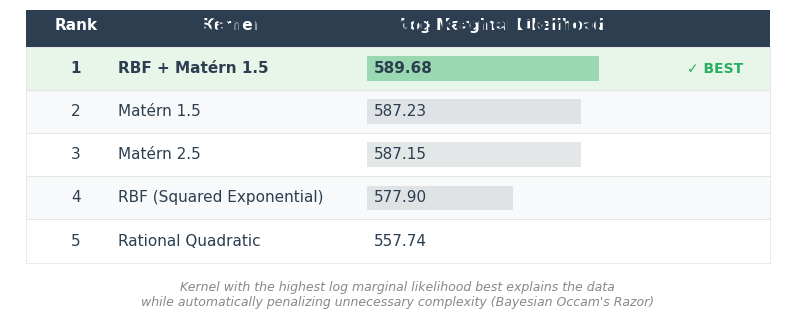

Saved: figures/09_kernel_table.png


In [2]:
# === KERNEL COMPARISON TABLE (PRESENTATION QUALITY) ===
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# Data
kernels = [
    ('RBF + Matérn 1.5', 589.68, True),
    ('Matérn 1.5', 587.23, False),
    ('Matérn 2.5', 587.15, False),
    ('RBF (Squared Exponential)', 577.90, False),
    ('Rational Quadratic', 557.74, False),
]

# Table structure
col_labels = ['Rank', 'Kernel', 'Log Marginal Likelihood', '']
n_rows = len(kernels)

# Colors
header_color = '#2C3E50'
best_row_color = '#E8F5E9'
alt_row_colors = ['#FFFFFF', '#F8F9FA']
accent_green = '#27AE60'
text_dark = '#2C3E50'
text_light = '#FFFFFF'

# Draw table manually for full control
row_height = 0.14
header_y = 0.88
start_y = header_y - row_height

col_x = [0.05, 0.12, 0.45, 0.82]
col_widths = [0.07, 0.33, 0.37, 0.18]

# Header row
ax.add_patch(plt.Rectangle((0.02, header_y), 0.96, row_height,
             facecolor=header_color, edgecolor='none', transform=ax.transAxes))
for j, label in enumerate(col_labels):
    ax.text(col_x[j] + col_widths[j]/2, header_y + row_height/2, label,
            ha='center', va='center', fontsize=11, fontweight='bold',
            color=text_light, transform=ax.transAxes)

# Data rows
for i, (name, lml, is_best) in enumerate(kernels):
    y = start_y - i * row_height
    
    if is_best:
        bg = best_row_color
    else:
        bg = alt_row_colors[i % 2]
    
    ax.add_patch(plt.Rectangle((0.02, y), 0.96, row_height,
                 facecolor=bg, edgecolor='#E0E0E0', linewidth=0.5,
                 transform=ax.transAxes))
    
    # Rank
    ax.text(col_x[0] + col_widths[0]/2, y + row_height/2, str(i + 1),
            ha='center', va='center', fontsize=11, color=text_dark,
            fontweight='bold' if is_best else 'normal',
            transform=ax.transAxes)
    
    # Kernel name
    ax.text(col_x[1] + 0.02, y + row_height/2, name,
            ha='left', va='center', fontsize=11, color=text_dark,
            fontweight='bold' if is_best else 'normal',
            transform=ax.transAxes)
    
    # LML value with bar
    max_lml = 589.68
    min_lml = 557.74
    bar_width = 0.30 * (lml - min_lml) / (max_lml - min_lml)
    
    bar_color = accent_green if is_best else '#BDC3C7'
    ax.add_patch(plt.Rectangle((col_x[2] + 0.01, y + 0.03), bar_width, row_height - 0.06,
                 facecolor=bar_color, edgecolor='none', alpha=0.4,
                 transform=ax.transAxes))
    
    ax.text(col_x[2] + 0.02, y + row_height/2, f'{lml:.2f}',
            ha='left', va='center', fontsize=11, color=text_dark,
            fontweight='bold' if is_best else 'normal',
            transform=ax.transAxes)
    
    # Badge
    if is_best:
        ax.text(col_x[3] + col_widths[3]/2, y + row_height/2, '✓ BEST',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color=accent_green, transform=ax.transAxes)

# Title
ax.text(0.5, 0.98, 'Bayesian Model Selection: Kernel Comparison',
        ha='center', va='top', fontsize=14, fontweight='bold',
        color=text_dark, transform=ax.transAxes)

# Subtitle
ax.text(0.5, 0.12, 
        'Kernel with the highest log marginal likelihood best explains the data\n'
        'while automatically penalizing unnecessary complexity (Bayesian Occam\'s Razor)',
        ha='center', va='top', fontsize=9, color='#888888',
        style='italic', transform=ax.transAxes)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.savefig('figures/09_kernel_table.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: figures/09_kernel_table.png')

  NBA WIN PROBABILITY: LIVE GP PREDICTION



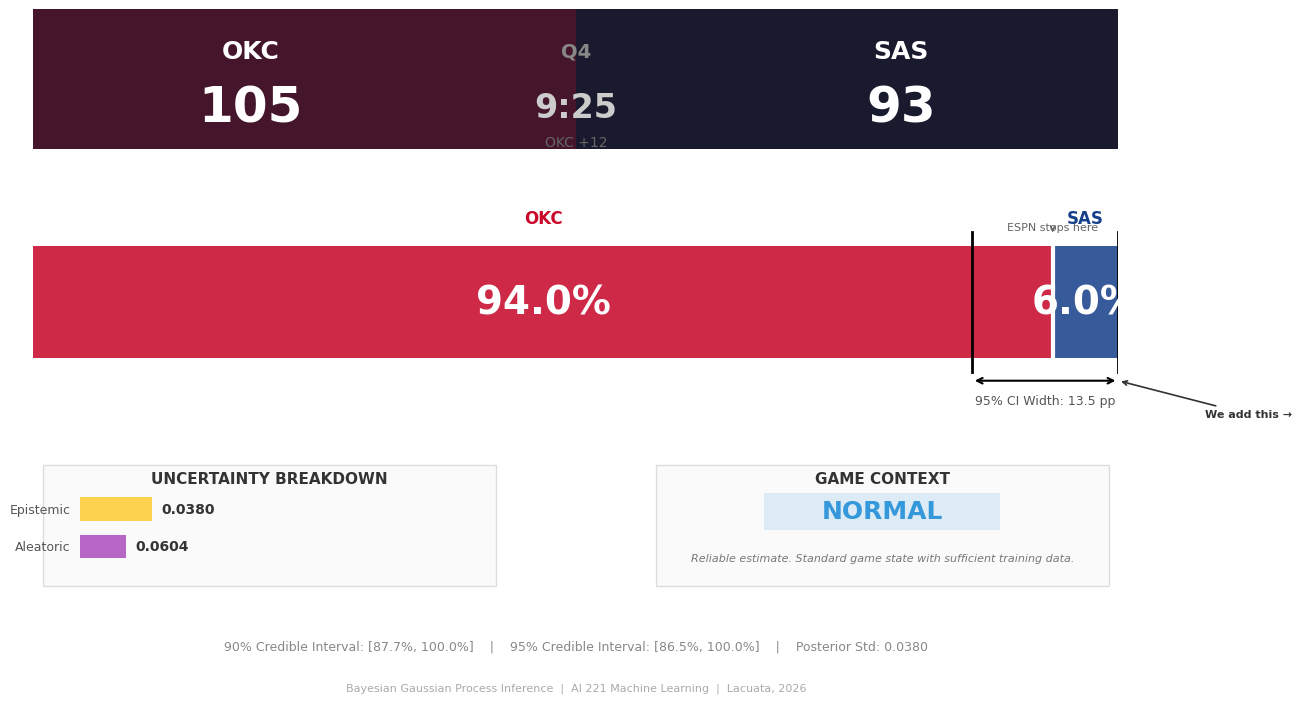


  OKC 105 - 93 SAS
  Q4 9:25 | Margin: +12
  P(OKC Win):   94.0%
  P(SAS Win):   6.0%
  Epistemic Std:     0.0380
  Aleatoric Proxy:   0.0604
  90% CI:            [87.7%, 100.0%]
  95% CI:            [86.5%, 100.0%]
  Context:           NORMAL


In [7]:
# === LIVE GP PREDICTION DEMO ===
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    best_gp
except NameError:
    with open('data/processed/best_gp_model.pkl', 'rb') as f:
        best_gp = pickle.load(f)
    with open('data/processed/scaler_gp.pkl', 'rb') as f:
        scaler_gp = pickle.load(f)

# === INPUT SECTION ===
print('=' * 50)
print('  NBA WIN PROBABILITY: LIVE GP PREDICTION')
print('=' * 50)
print()

home_team = input('  Home Team: ')
away_team = input('  Away Team: ')
home_score = int(input('  Home Score: '))
away_score = int(input('  Away Score: '))
quarter = int(input('  Quarter (1-4): '))
minutes = int(input('  Minutes Left in Quarter: '))
seconds = int(input('  Seconds Left in Quarter: '))

# === COMPUTE ===
margin = home_score - away_score
total_seconds = (4 - quarter) * 720 + minutes * 60 + seconds

X = scaler_gp.transform([[margin, total_seconds]])
prob, std = best_gp.predict(X, return_std=True)
prob = np.clip(prob[0], 0, 1)
std = std[0]

away_prob = 1 - prob
ci90 = (max(0, prob - 1.645 * std), min(1, prob + 1.645 * std))
ci95 = (max(0, prob - 1.96 * std), min(1, prob + 1.96 * std))
epistemic = std
aleatoric = 0.5 - abs(prob - 0.5)

# === DETERMINE CONTEXT ===
if abs(margin) >= 15:
    context = 'BLOWOUT'
    context_color = '#E74C3C'
    context_note = 'Outcome is likely but model has limited data here. Trust with caution.'
elif abs(margin) <= 5 and total_seconds <= 300:
    context = 'CLUTCH'
    context_color = '#F39C12'
    context_note = 'Model is confident but outcome is volatile. High-risk decisions not advised.'
else:
    context = 'NORMAL'
    context_color = '#3498DB'
    context_note = 'Reliable estimate. Standard game state with sufficient training data.'

# === COLORS ===
home_color = '#C9082A'
away_color = '#17408B'
bg_light = '#FAFAFA'

# === BUILD VISUAL ===
fig = plt.figure(figsize=(14, 9), facecolor='white')
gs = fig.add_gridspec(4, 2, height_ratios=[1.5, 3, 1.5, 1], hspace=0.08, wspace=0.3)

# --- TOP BANNER: SCOREBOARD ---
ax_score = fig.add_subplot(gs[0, :])
ax_score.axis('off')
ax_score.set_xlim(0, 10)
ax_score.set_ylim(0, 1)

ax_score.add_patch(plt.Rectangle((0, 0), 10, 1, facecolor='#1a1a2e', edgecolor='none'))

# Split background by who is leading
ax_score.add_patch(plt.Rectangle((0, 0), 5, 1, facecolor='#1a1a2e', edgecolor='none'))
ax_score.add_patch(plt.Rectangle((5, 0), 5, 1, facecolor='#1a1a2e', edgecolor='none'))
if margin > 0:
    ax_score.add_patch(plt.Rectangle((0, 0), 5, 1, facecolor=home_color, alpha=0.25, edgecolor='none'))
elif margin < 0:
    ax_score.add_patch(plt.Rectangle((5, 0), 5, 1, facecolor=away_color, alpha=0.25, edgecolor='none'))

# Home side
ax_score.text(2, 0.7, home_team.upper(), ha='center', va='center',
              fontsize=18, fontweight='bold', color='white')
ax_score.text(2, 0.3, str(home_score), ha='center', va='center',
              fontsize=36, fontweight='bold', color='white')

# Away side
ax_score.text(8, 0.7, away_team.upper(), ha='center', va='center',
              fontsize=18, fontweight='bold', color='white')
ax_score.text(8, 0.3, str(away_score), ha='center', va='center',
              fontsize=36, fontweight='bold', color='white')

# Center: quarter and time
ax_score.text(5, 0.7, f'Q{quarter}', ha='center', va='center',
              fontsize=14, fontweight='bold', color='#888888')
ax_score.text(5, 0.3, f'{minutes}:{seconds:02d}', ha='center', va='center',
              fontsize=24, fontweight='bold', color='#cccccc')

# Margin indicator
sign = '+' if margin > 0 else ''
leading = home_team.upper() if margin > 0 else away_team.upper() if margin < 0 else 'TIED'
if margin != 0:
    ax_score.text(5, 0.05, f'{leading} {sign}{abs(margin)}',
                  ha='center', va='center', fontsize=10, color='#666666')
else:
    ax_score.text(5, 0.05, 'TIED', ha='center', va='center',
                  fontsize=10, color='#666666')

# --- MAIN: PROBABILITY BAR ---
ax_bar = fig.add_subplot(gs[1, :])
ax_bar.axis('off')
ax_bar.set_xlim(0, 100)
ax_bar.set_ylim(0, 10)

# Background bar
ax_bar.add_patch(plt.Rectangle((0, 3), 100, 4, facecolor='#eeeeee', edgecolor='none'))

# Home probability fill
ax_bar.add_patch(plt.Rectangle((0, 3), prob * 100, 4,
                 facecolor=home_color, alpha=0.85, edgecolor='none'))

# Away probability fill
ax_bar.add_patch(plt.Rectangle((prob * 100, 3), away_prob * 100, 4,
                 facecolor=away_color, alpha=0.85, edgecolor='none'))

# 95% CI markers
ci_left = ci95[0] * 100
ci_right = ci95[1] * 100
ax_bar.plot([ci_left, ci_left], [2.5, 7.5], color='black', linewidth=2, zorder=5)
ax_bar.plot([ci_right, ci_right], [2.5, 7.5], color='black', linewidth=2, zorder=5)
ax_bar.annotate('', xy=(ci_left, 2.2), xytext=(ci_right, 2.2),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax_bar.text((ci_left + ci_right) / 2, 1.5, f'95% CI Width: {(ci_right - ci_left):.1f} pp',
            ha='center', va='center', fontsize=9, color='#555555')

# Center divider
ax_bar.plot([prob * 100, prob * 100], [2.8, 7.2], color='white', linewidth=3, zorder=6)

# ESPN comparison annotation
ax_bar.annotate('ESPN stops here', xy=(prob * 100, 7.5), fontsize=8,
                ha='center', va='bottom', color='#666666',
                arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2))
ax_bar.annotate('We add this →', xy=(ci_right, 2.2), xytext=(ci_right + 8, 1.0),
                fontsize=8, ha='left', va='center', color='#333333', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2))

# Home probability text
ax_bar.text(prob * 100 / 2, 5, f'{prob:.1%}', ha='center', va='center',
            fontsize=28, fontweight='bold', color='white', zorder=7)
ax_bar.text(prob * 100 / 2, 8, home_team.upper(), ha='center', va='center',
            fontsize=12, fontweight='bold', color=home_color)

# Away probability text
ax_bar.text(prob * 100 + away_prob * 100 / 2, 5, f'{away_prob:.1%}', ha='center', va='center',
            fontsize=28, fontweight='bold', color='white', zorder=7)
ax_bar.text(prob * 100 + away_prob * 100 / 2, 8, away_team.upper(), ha='center', va='center',
            fontsize=12, fontweight='bold', color=away_color)

# --- UNCERTAINTY PANEL ---
ax_unc = fig.add_subplot(gs[2, 0])
ax_unc.axis('off')
ax_unc.set_xlim(0, 10)
ax_unc.set_ylim(0, 3)

ax_unc.add_patch(plt.Rectangle((0.2, 0.2), 9.6, 2.6, facecolor=bg_light,
                 edgecolor='#dddddd', linewidth=1, transform=ax_unc.transData))

ax_unc.text(5, 2.5, 'UNCERTAINTY BREAKDOWN', ha='center', va='center',
            fontsize=11, fontweight='bold', color='#333333')

# Epistemic bar
ep_width = min(epistemic / 0.1 * 4, 8)
ax_unc.add_patch(plt.Rectangle((1, 1.6), ep_width, 0.5,
                 facecolor='#FFC107', alpha=0.7, edgecolor='none'))
ax_unc.text(0.8, 1.85, 'Epistemic', ha='right', va='center', fontsize=9, color='#555555')
ax_unc.text(1 + ep_width + 0.2, 1.85, f'{epistemic:.4f}', ha='left', va='center',
            fontsize=10, fontweight='bold', color='#333333')

# Aleatoric bar
al_width = min(aleatoric / 0.5 * 8, 8)
ax_unc.add_patch(plt.Rectangle((1, 0.8), al_width, 0.5,
                 facecolor='#9C27B0', alpha=0.7, edgecolor='none'))
ax_unc.text(0.8, 1.05, 'Aleatoric', ha='right', va='center', fontsize=9, color='#555555')
ax_unc.text(1 + al_width + 0.2, 1.05, f'{aleatoric:.4f}', ha='left', va='center',
            fontsize=10, fontweight='bold', color='#333333')

# --- CONTEXT PANEL ---
ax_ctx = fig.add_subplot(gs[2, 1])
ax_ctx.axis('off')
ax_ctx.set_xlim(0, 10)
ax_ctx.set_ylim(0, 3)

ax_ctx.add_patch(plt.Rectangle((0.2, 0.2), 9.6, 2.6, facecolor=bg_light,
                 edgecolor='#dddddd', linewidth=1, transform=ax_ctx.transData))

ax_ctx.text(5, 2.5, 'GAME CONTEXT', ha='center', va='center',
            fontsize=11, fontweight='bold', color='#333333')

# Context badge
ax_ctx.add_patch(plt.Rectangle((2.5, 1.4), 5, 0.8, facecolor=context_color,
                 edgecolor='none', alpha=0.15, transform=ax_ctx.transData))
ax_ctx.text(5, 1.8, context, ha='center', va='center',
            fontsize=18, fontweight='bold', color=context_color)

# Context explanation
ax_ctx.text(5, 0.8, context_note, ha='center', va='center',
            fontsize=8, color='#777777', style='italic', wrap=True)

# --- FOOTER ---
ax_foot = fig.add_subplot(gs[3, :])
ax_foot.axis('off')
ax_foot.set_xlim(0, 10)
ax_foot.set_ylim(0, 1)

ax_foot.text(5, 0.6, 
    f'90% Credible Interval: [{ci90[0]:.1%}, {ci90[1]:.1%}]    |    '
    f'95% Credible Interval: [{ci95[0]:.1%}, {ci95[1]:.1%}]    |    '
    f'Posterior Std: {std:.4f}',
    ha='center', va='center', fontsize=9, color='#888888')

ax_foot.text(5, 0.15, 'Bayesian Gaussian Process Inference  |  AI 221 Machine Learning  |  Lacuata, 2026',
             ha='center', va='center', fontsize=8, color='#aaaaaa')

plt.savefig('figures/10_live_prediction.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# === CONSOLE SUMMARY ===
print()
print('=' * 50)
print(f'  {home_team.upper()} {home_score} - {away_score} {away_team.upper()}')
print(f'  Q{quarter} {minutes}:{seconds:02d} | Margin: {sign}{margin}')
print('=' * 50)
print(f'  P({home_team} Win):   {prob:.1%}')
print(f'  P({away_team} Win):   {away_prob:.1%}')
print(f'  Epistemic Std:     {epistemic:.4f}')
print(f'  Aleatoric Proxy:   {aleatoric:.4f}')
print(f'  90% CI:            [{ci90[0]:.1%}, {ci90[1]:.1%}]')
print(f'  95% CI:            [{ci95[0]:.1%}, {ci95[1]:.1%}]')
print(f'  Context:           {context}')
print('=' * 50)

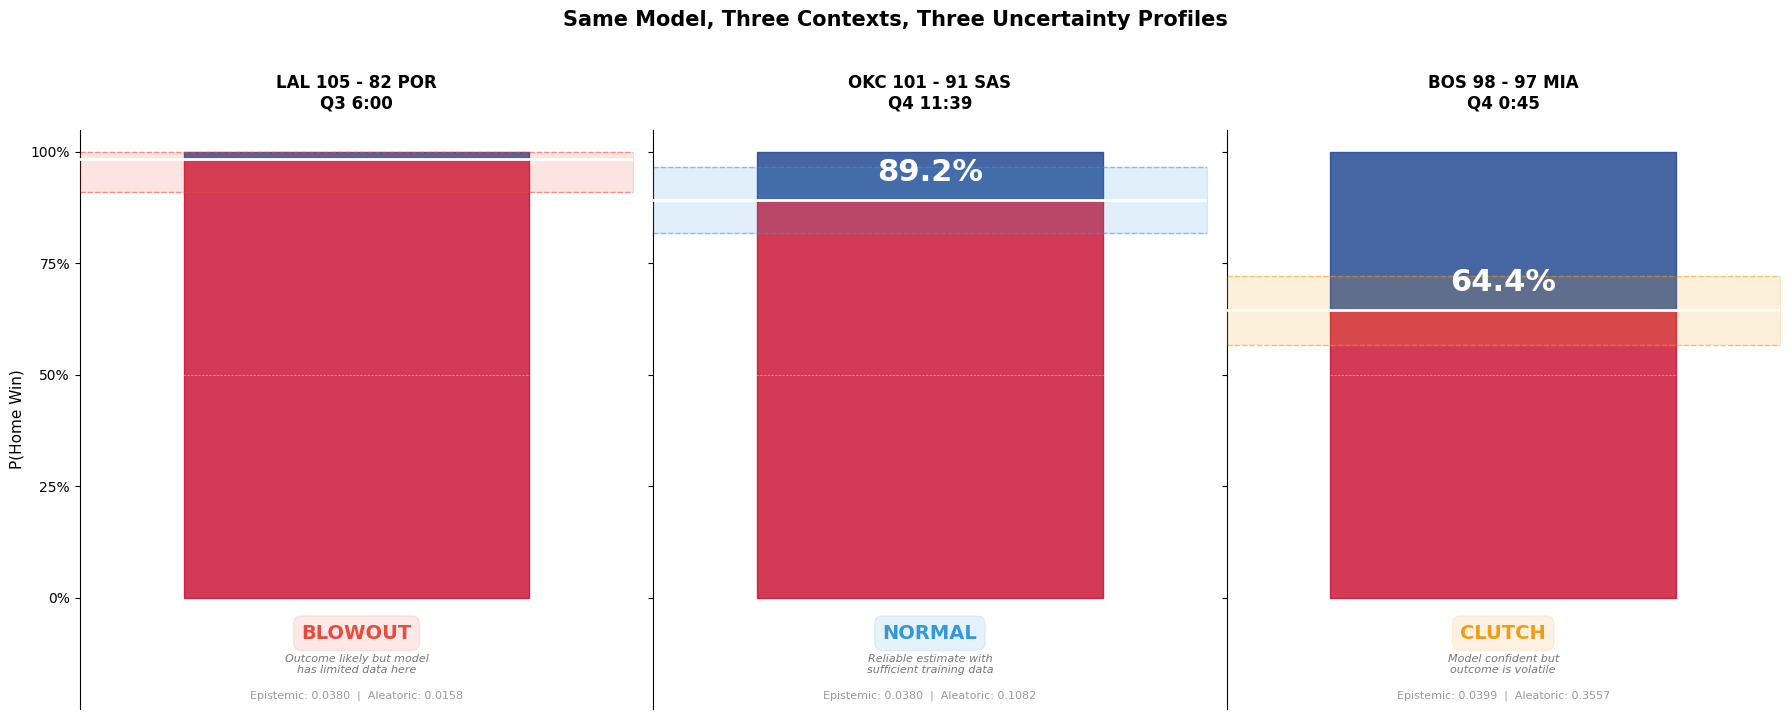

In [8]:
# === THREE-SCENARIO COMPARISON (NO INPUT NEEDED) ===
scenarios = [
    {'label': 'BLOWOUT', 'home': 'LAL', 'away': 'POR', 'hs': 105, 'as': 82, 'q': 3, 'm': 6, 's': 0},
    {'label': 'NORMAL', 'home': 'OKC', 'away': 'SAS', 'hs': 101, 'as': 91, 'q': 4, 'm': 11, 's': 39},
    {'label': 'CLUTCH', 'home': 'BOS', 'away': 'MIA', 'hs': 98, 'as': 97, 'q': 4, 'm': 0, 's': 45},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

colors = {'BLOWOUT': '#E74C3C', 'NORMAL': '#3498DB', 'CLUTCH': '#F39C12'}
notes = {
    'BLOWOUT': 'Outcome likely but model\nhas limited data here',
    'NORMAL': 'Reliable estimate with\nsufficient training data',
    'CLUTCH': 'Model confident but\noutcome is volatile',
}

for ax, sc in zip(axes, scenarios):
    margin = sc['hs'] - sc['as']
    secs = (4 - sc['q']) * 720 + sc['m'] * 60 + sc['s']
    X = scaler_gp.transform([[margin, secs]])
    p, s = best_gp.predict(X, return_std=True)
    p = np.clip(p[0], 0, 1)
    s = s[0]
    aleat = 0.5 - abs(p - 0.5)
    ci95 = (max(0, p - 1.96*s), min(1, p + 1.96*s))
    
    c = colors[sc['label']]
    
    # Probability fill
    ax.fill_between([0, 1], 0, p * 100, color='#C9082A', alpha=0.8)
    ax.fill_between([0, 1], p * 100, 100, color='#17408B', alpha=0.8)
    
    # CI band
    ax.fill_between([-0.3, 1.3], ci95[0]*100, ci95[1]*100, color=c, alpha=0.15, zorder=3)
    ax.plot([-0.3, 1.3], [ci95[0]*100, ci95[0]*100], color=c, lw=1, ls='--', alpha=0.5)
    ax.plot([-0.3, 1.3], [ci95[1]*100, ci95[1]*100], color=c, lw=1, ls='--', alpha=0.5)
    
    # Probability line
    ax.axhline(p * 100, color='white', lw=2, zorder=4)
    
    # 50% line
    ax.axhline(50, color='white', lw=0.5, ls='--', alpha=0.5)
    
    # Probability label
    ax.text(0.5, p * 100 + 3, f'{p:.1%}', ha='center', va='bottom',
            fontsize=22, fontweight='bold', color='white', zorder=5)
    
    # Scoreboard
    ax.set_title(f'{sc["home"]} {sc["hs"]} - {sc["as"]} {sc["away"]}\n'
                 f'Q{sc["q"]} {sc["m"]}:{sc["s"]:02d}',
                 fontsize=12, fontweight='bold', pad=15)
    
    # Context badge at bottom
    ax.text(0.5, -8, sc['label'], ha='center', va='center',
            fontsize=14, fontweight='bold', color=c,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=c, alpha=0.12, edgecolor=c))
    ax.text(0.5, -15, notes[sc['label']], ha='center', va='center',
            fontsize=8, color='#777777', style='italic')
    
    # Uncertainty text
    ax.text(0.5, -22, f'Epistemic: {s:.4f}  |  Aleatoric: {aleat:.4f}',
            ha='center', va='center', fontsize=8, color='#999999')
    
    # Clean up
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-25, 105)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

axes[0].set_yticks([0, 25, 50, 75, 100])
axes[0].set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
axes[0].set_ylabel('P(Home Win)', fontsize=11)

plt.suptitle('Same Model, Three Contexts, Three Uncertainty Profiles', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/11_three_scenarios.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

In [9]:
# Find the confidently wrong game ID and details
game_avg = test_snaps.groupby('GAME_ID').agg(
    avg_gp=('gp_mean', 'mean') if 'gp_mean' in test_snaps.columns else ('HOME_WIN', 'mean'),
    home_win=('HOME_WIN', 'first')
).reset_index()

# If gp_mean not in test_snaps, recompute
if 'gp_mean' not in test_snaps.columns:
    X_all = scaler_gp.transform(test_snaps[['SCORE_MARGIN', 'SECONDS_REMAINING']].values)
    preds, _ = best_gp.predict(X_all, return_std=True)
    test_snaps['gp_mean'] = np.clip(preds, 0, 1)
    game_avg = test_snaps.groupby('GAME_ID').agg(
        avg_gp=('gp_mean', 'mean'),
        home_win=('HOME_WIN', 'first')
    ).reset_index()

confident_wrong = game_avg[(game_avg['home_win'] == 0) & (game_avg['avg_gp'] > 0.65)]
confident_wrong = confident_wrong.sort_values('avg_gp', ascending=False)
print(confident_wrong[['GAME_ID', 'avg_gp']].head(5))

       GAME_ID    avg_gp
112   22300113  0.828004
1044  22301045  0.821597
140   22300141  0.792601
740   22300741  0.782892
419   22300420  0.764468


In [10]:
# Look up game details from game logs
game_logs = pd.read_csv('data/raw/nba_game_logs.csv')

target_ids = ['22300113', '22301045', '22300141', '22300741', '22300420']

for gid in target_ids:
    match = game_logs[game_logs['GAME_ID'].astype(str) == gid]
    if len(match) > 0:
        home = match[match['MATCHUP'].str.contains('vs.')].iloc[0]
        away = match[match['MATCHUP'].str.contains('@')].iloc[0]
        print(f'Game {gid}: {home["TEAM_ABBREVIATION"]} vs {away["TEAM_ABBREVIATION"]} | '
              f'{home["PTS"]:.0f}-{away["PTS"]:.0f} | {home["GAME_DATE"]} | '
              f'Home {"Won" if home["WL"]=="W" else "Lost"}')
    print()

Game 22300113: PHX vs SAS | 114-115 | 2023-10-31 | Home Lost

Game 22301045: MIL vs LAL | 124-128 | 2024-03-26 | Home Lost

Game 22300141: SAS vs TOR | 116-123 | 2023-11-05 | Home Lost

Game 22300741: POR vs DET | 122-128 | 2024-02-08 | Home Lost

Game 22300420: DAL vs CLE | 110-113 | 2023-12-27 | Home Lost



c:\Users\Josh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Josh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


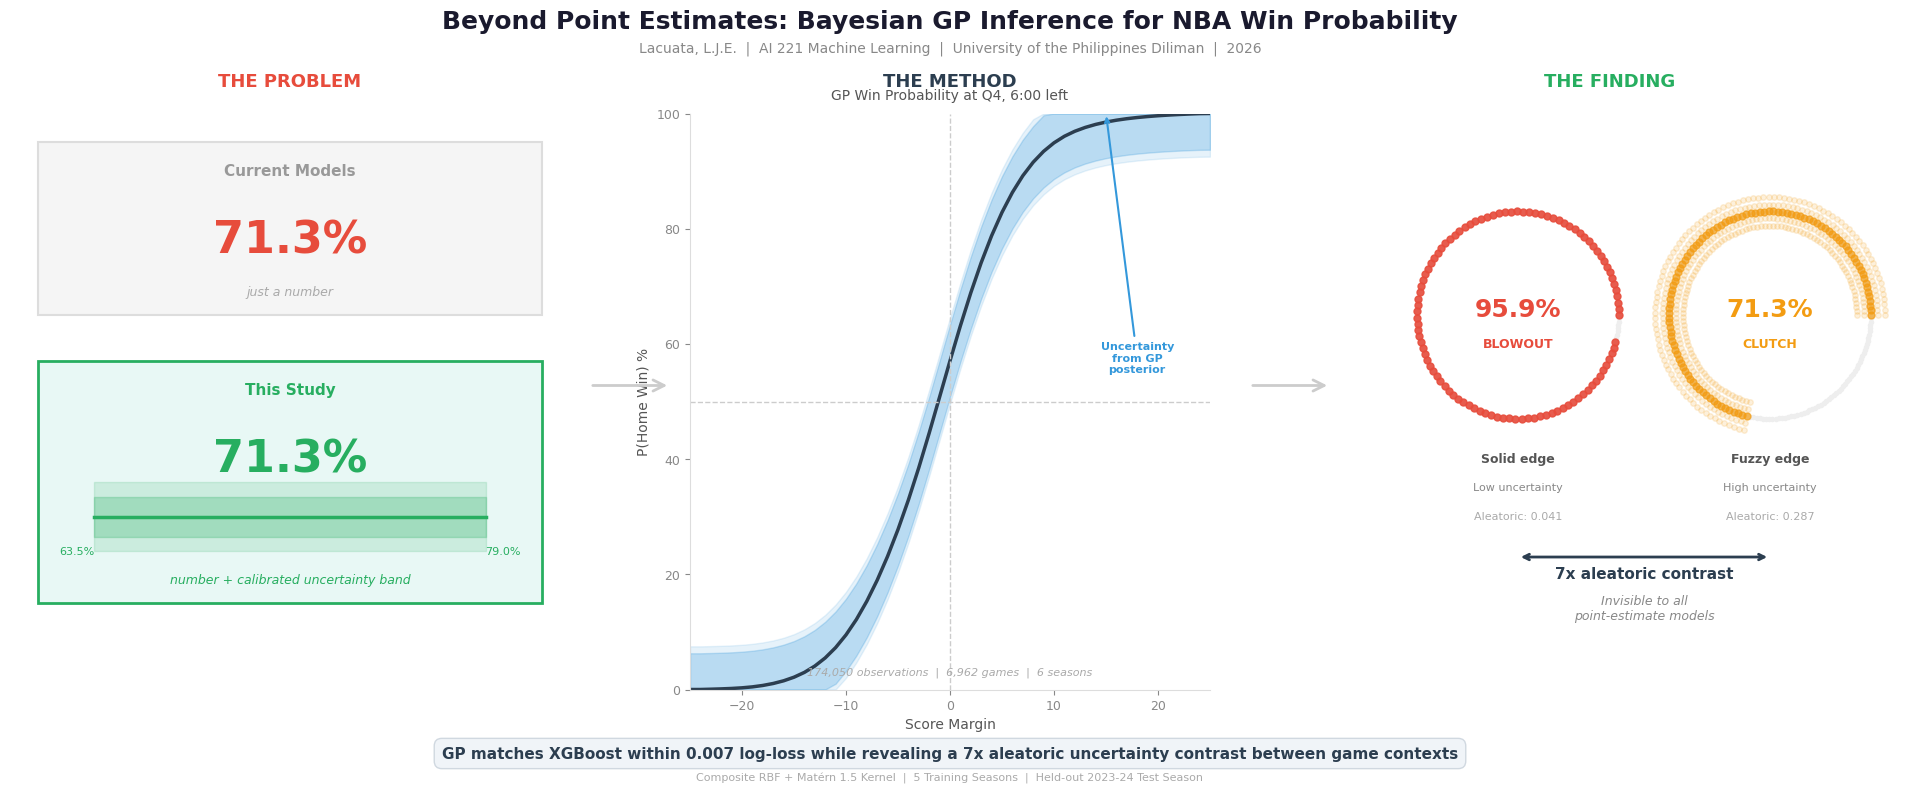

Saved: figures/graphical_abstract.png


In [1]:
# === GRAPHICAL ABSTRACT ===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import pickle

try:
    best_gp
except NameError:
    with open('data/processed/best_gp_model.pkl', 'rb') as f:
        best_gp = pickle.load(f)
    with open('data/processed/scaler_gp.pkl', 'rb') as f:
        scaler_gp = pickle.load(f)

fig = plt.figure(figsize=(20, 8), facecolor='white')

# Overall title
fig.text(0.5, 0.97, 'Beyond Point Estimates: Bayesian GP Inference for NBA Win Probability',
         ha='center', va='top', fontsize=18, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.93, 'Lacuata, L.J.E.  |  AI 221 Machine Learning  |  University of the Philippines Diliman  |  2026',
         ha='center', va='top', fontsize=10, color='#888888')

# Column labels
fig.text(0.17, 0.88, 'THE PROBLEM', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#E74C3C')
fig.text(0.5, 0.88, 'THE METHOD', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#2C3E50')
fig.text(0.83, 0.88, 'THE FINDING', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#27AE60')

# Arrows between columns
fig.patches.append(FancyArrowPatch(
    (0.32, 0.50), (0.36, 0.50), transform=fig.transFigure,
    arrowstyle='->', mutation_scale=20, lw=2, color='#cccccc'))
fig.patches.append(FancyArrowPatch(
    (0.65, 0.50), (0.69, 0.50), transform=fig.transFigure,
    arrowstyle='->', mutation_scale=20, lw=2, color='#cccccc'))

# ============================
# LEFT PANEL: THE PROBLEM
# ============================
ax_left = fig.add_axes([0.03, 0.12, 0.28, 0.72])
ax_left.axis('off')
ax_left.set_xlim(0, 10)
ax_left.set_ylim(0, 10)

# ESPN version (top)
ax_left.add_patch(plt.Rectangle((0.5, 6.5), 9, 3, facecolor='#f5f5f5',
                  edgecolor='#dddddd', linewidth=1.5))
ax_left.text(5, 9, 'Current Models', ha='center', va='center',
             fontsize=11, fontweight='bold', color='#999999')
ax_left.text(5, 7.8, '71.3%', ha='center', va='center',
             fontsize=32, fontweight='bold', color='#E74C3C')
ax_left.text(5, 6.9, 'just a number', ha='center', va='center',
             fontsize=9, color='#aaaaaa', style='italic')

# Our version (bottom)
ax_left.add_patch(plt.Rectangle((0.5, 1.5), 9, 4.2, facecolor='#E8F8F5',
                  edgecolor='#27AE60', linewidth=2))
ax_left.text(5, 5.2, 'This Study', ha='center', va='center',
             fontsize=11, fontweight='bold', color='#27AE60')
ax_left.text(5, 4.0, '71.3%', ha='center', va='center',
             fontsize=32, fontweight='bold', color='#27AE60')

# Uncertainty band visualization
band_x = np.linspace(1.5, 8.5, 100)
band_center = np.ones_like(band_x) * 3.0
ax_left.fill_between(band_x, band_center - 0.6, band_center + 0.6,
                     color='#27AE60', alpha=0.15)
ax_left.fill_between(band_x, band_center - 0.35, band_center + 0.35,
                     color='#27AE60', alpha=0.25)
ax_left.plot(band_x, band_center, color='#27AE60', linewidth=2.5)

ax_left.text(1.2, 2.4, '63.5%', ha='center', va='center', fontsize=8, color='#27AE60')
ax_left.text(8.8, 2.4, '79.0%', ha='center', va='center', fontsize=8, color='#27AE60')
ax_left.text(5, 1.9, 'number + calibrated uncertainty band', ha='center', va='center',
             fontsize=9, color='#27AE60', style='italic')

# ============================
# CENTER PANEL: THE METHOD
# ============================
ax_center = fig.add_axes([0.37, 0.12, 0.26, 0.72])

# Generate a clean 1D slice: win prob vs margin at Q4 6:00 (360 seconds)
margins_slice = np.arange(-25, 26, 1)
time_fixed = 360  # Q4, 6:00 left
X_slice = np.column_stack([margins_slice, np.full_like(margins_slice, time_fixed, dtype=float)])
X_slice_scaled = scaler_gp.transform(X_slice)
y_slice, std_slice = best_gp.predict(X_slice_scaled, return_std=True)
y_slice = np.clip(y_slice, 0, 1)

# Plot
ax_center.fill_between(margins_slice, 
                       np.clip(y_slice - 1.96 * std_slice, 0, 1) * 100,
                       np.clip(y_slice + 1.96 * std_slice, 0, 1) * 100,
                       color='#3498DB', alpha=0.12, label='95% Credible Interval')
ax_center.fill_between(margins_slice,
                       np.clip(y_slice - 1.645 * std_slice, 0, 1) * 100,
                       np.clip(y_slice + 1.645 * std_slice, 0, 1) * 100,
                       color='#3498DB', alpha=0.25, label='90% Credible Interval')
ax_center.plot(margins_slice, y_slice * 100, color='#2C3E50', linewidth=2.5,
               label='GP Posterior Mean')

ax_center.axhline(50, color='#cccccc', linestyle='--', linewidth=1)
ax_center.axvline(0, color='#cccccc', linestyle='--', linewidth=1)

# Annotation pointing to band
ax_center.annotate('Uncertainty\nfrom GP\nposterior',
                   xy=(15, np.clip(y_slice[40] + 1.96 * std_slice[40], 0, 1) * 100),
                   xytext=(18, 55), fontsize=8, color='#3498DB', fontweight='bold',
                   ha='center',
                   arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.5))

ax_center.set_xlim(-25, 25)
ax_center.set_ylim(0, 100)
ax_center.set_xlabel('Score Margin', fontsize=10, color='#555555')
ax_center.set_ylabel('P(Home Win) %', fontsize=10, color='#555555')
ax_center.set_title('GP Win Probability at Q4, 6:00 left', fontsize=10,
                    color='#555555', pad=10)
ax_center.spines['top'].set_visible(False)
ax_center.spines['right'].set_visible(False)
ax_center.spines['left'].set_color('#dddddd')
ax_center.spines['bottom'].set_color('#dddddd')
ax_center.tick_params(colors='#888888', labelsize=9)

# Data badge
ax_center.text(0.5, 0.02, '174,050 observations  |  6,962 games  |  6 seasons',
               transform=ax_center.transAxes, ha='center', va='bottom',
               fontsize=8, color='#aaaaaa', style='italic')

# ============================
# RIGHT PANEL: THE FINDING
# ============================
ax_right = fig.add_axes([0.70, 0.12, 0.28, 0.72])
ax_right.axis('off')
ax_right.set_xlim(0, 10)
ax_right.set_ylim(0, 10)

# --- BLOWOUT DONUT (left side) ---
center_b = (3, 6.5)
radius = 1.8
# Solid fill for high probability
theta_fill = np.linspace(0, 2 * np.pi * 0.959, 100)
theta_bg = np.linspace(2 * np.pi * 0.959, 2 * np.pi, 20)

# Background ring
for t in np.linspace(0, 2 * np.pi, 200):
    ax_right.plot(center_b[0] + radius * np.cos(t), center_b[1] + radius * np.sin(t),
                  'o', color='#eeeeee', markersize=3)

# Solid fill ring (tight, confident)
for t in theta_fill:
    ax_right.plot(center_b[0] + radius * np.cos(t), center_b[1] + radius * np.sin(t),
                  'o', color='#E74C3C', markersize=5, alpha=0.9)

# Center text
ax_right.text(center_b[0], center_b[1] + 0.1, '95.9%', ha='center', va='center',
              fontsize=18, fontweight='bold', color='#E74C3C')
ax_right.text(center_b[0], center_b[1] - 0.5, 'BLOWOUT', ha='center', va='center',
              fontsize=9, fontweight='bold', color='#E74C3C')

# Label below
ax_right.text(center_b[0], 4.0, 'Solid edge', ha='center', va='center',
              fontsize=9, fontweight='bold', color='#555555')
ax_right.text(center_b[0], 3.5, 'Low uncertainty', ha='center', va='center',
              fontsize=8, color='#888888')
ax_right.text(center_b[0], 3.0, f'Aleatoric: 0.041', ha='center', va='center',
              fontsize=8, color='#aaaaaa')

# --- CLUTCH DONUT (right side) ---
center_c = (7.5, 6.5)

# Background ring
for t in np.linspace(0, 2 * np.pi, 200):
    ax_right.plot(center_c[0] + radius * np.cos(t), center_c[1] + radius * np.sin(t),
                  'o', color='#eeeeee', markersize=3)

# Fuzzy fill ring (wide, uncertain)
theta_fill_c = np.linspace(0, 2 * np.pi * 0.713, 100)
for t in theta_fill_c:
    # Multiple layers with jitter for fuzzy effect
    for dr in [-0.25, -0.12, 0, 0.12, 0.25]:
        alpha = 0.7 if dr == 0 else 0.15
        ms = 5 if dr == 0 else 4
        ax_right.plot(center_c[0] + (radius + dr) * np.cos(t),
                     center_c[1] + (radius + dr) * np.sin(t),
                     'o', color='#F39C12', markersize=ms, alpha=alpha)

# Center text
ax_right.text(center_c[0], center_c[1] + 0.1, '71.3%', ha='center', va='center',
              fontsize=18, fontweight='bold', color='#F39C12')
ax_right.text(center_c[0], center_c[1] - 0.5, 'CLUTCH', ha='center', va='center',
              fontsize=9, fontweight='bold', color='#F39C12')

# Label below
ax_right.text(center_c[0], 4.0, 'Fuzzy edge', ha='center', va='center',
              fontsize=9, fontweight='bold', color='#555555')
ax_right.text(center_c[0], 3.5, 'High uncertainty', ha='center', va='center',
              fontsize=8, color='#888888')
ax_right.text(center_c[0], 3.0, f'Aleatoric: 0.287', ha='center', va='center',
              fontsize=8, color='#aaaaaa')

# 7x contrast label
ax_right.annotate('', xy=(3, 2.3), xytext=(7.5, 2.3),
                  arrowprops=dict(arrowstyle='<->', color='#2C3E50', lw=2))
ax_right.text(5.25, 2.0, '7x aleatoric contrast', ha='center', va='center',
              fontsize=11, fontweight='bold', color='#2C3E50')
ax_right.text(5.25, 1.4, 'Invisible to all\npoint-estimate models', ha='center', va='center',
              fontsize=9, color='#888888', style='italic')

# ============================
# BOTTOM STRIP
# ============================
fig.text(0.5, 0.04,
         'GP matches XGBoost within 0.007 log-loss while revealing a 7x aleatoric uncertainty contrast between game contexts',
         ha='center', va='center', fontsize=11, fontweight='bold', color='#2C3E50',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f4f8', edgecolor='#d0d8e0'))

fig.text(0.5, 0.01, 'Composite RBF + Matérn 1.5 Kernel  |  5 Training Seasons  |  Held-out 2023-24 Test Season',
         ha='center', va='center', fontsize=8, color='#aaaaaa')

plt.savefig('figures/graphical_abstract.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: figures/graphical_abstract.png')

In [2]:
import matplotlib as plt

In [5]:
import pandas as pd

In [8]:
import seaborn as sns

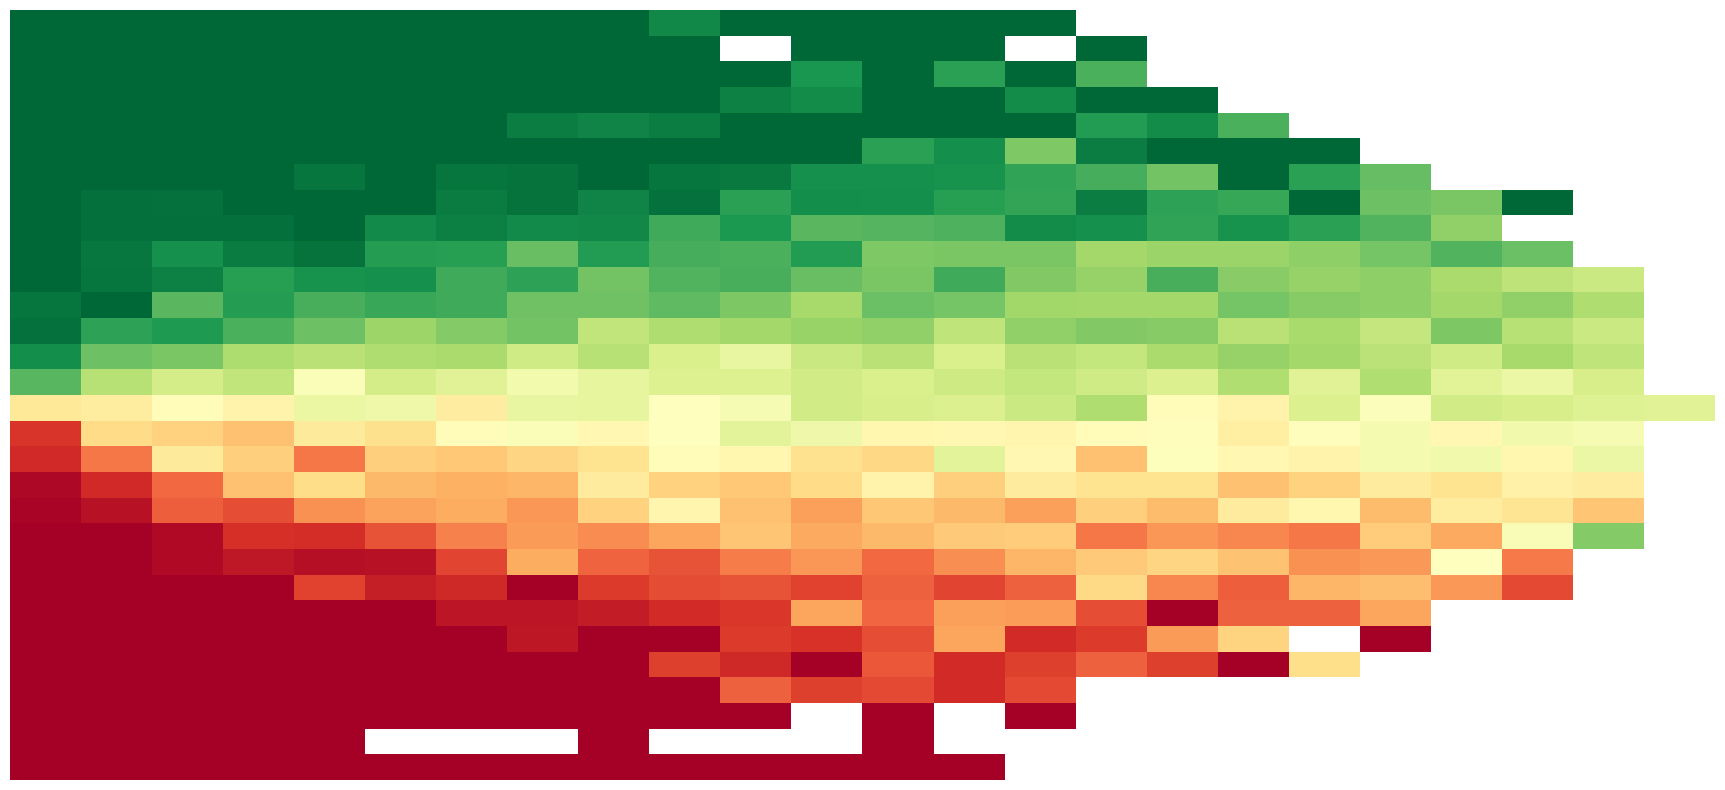

In [15]:
binned = pd.read_csv('data/processed/binned_train.csv')
heatmap_data = binned.pivot(index='MARGIN_BIN', columns='TIME_BIN', values='win_rate')

# Ensure plt references pyplot (fixes earlier `import matplotlib as plt`)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(22, 10))
sns.heatmap(
    heatmap_data.sort_index(ascending=False),
    cmap='RdYlGn', center=0.5, vmin=0, vmax=1,
    cbar=False, xticklabels=False, yticklabels=False
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.tick_params(left=False, bottom=False)

plt.savefig('figures/ga_heatmap_clean.png', dpi=300, bbox_inches='tight',
            pad_inches=0, facecolor='white')
plt.show()